In [66]:
# ============================================================
# 📁 GOOGLE DRIVE ULANISH
# ------------------------------------------------------------
# Google Colab muhitida Drive disk sifatida ulanadi.
# Bu qadamdan keyin /content/drive/MyDrive/ papkasiga
# fayllar saqlash va o'qish mumkin bo'ladi.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# ============================================================
# 📂 LOYIHA PAPKASINI YARATISH
# ------------------------------------------------------------
# Drive ichida 'imdb_lab' nomli papka yaratiladi.
# exist_ok=True: papka allaqachon bo'lsa xato bermaydi.
# %cd — ish papkasini shu joyga o'zgartiradi.
# ============================================================
import os
os.makedirs('/content/drive/MyDrive/imdb_lab', exist_ok=True)
%cd /content/drive/MyDrive/imdb_lab
print("Papka tayyor!")

/content/drive/MyDrive/imdb_lab
Papka tayyor!


In [68]:
# ============================================================
# 🔑 KAGGLE API KALITINI SOZLASH
# ------------------------------------------------------------
# Kaggle dan dataset yuklab olish uchun API token kerak.
# Token ~/.kaggle/kaggle.json fayliga yoziladi.
# chmod 0o600 — faqat o'zingiz o'qiy olasiz (xavfsizlik).
# ⚠️  Haqiqiy loyihada API kalitni kodni ichiga YOZMANG!
#     Environment variable yoki secrets ishlatish tavsiya etiladi.
# ============================================================
import os, json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_token = {"username": "aizenlee", "key": "e60fdfd54072cfd61aacedb547efba8c"}
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_token, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("Kaggle tayyor!")

Kaggle tayyor!


In [69]:
# ============================================================
# ⬇️  KAGGLE DAN DATASET YUKLAB OLISH
# ------------------------------------------------------------
# kagglehub kutubxonasi orqali IMDb extensive dataset yuklanadi.
# Yuklab olingan fayl path o'zgaruvchisida saqlanadi.
# ============================================================
import kagglehub

# Download latest version
path = kagglehub.dataset_download("simhyunsu/imdbextensivedataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/simhyunsu/imdbextensivedataset/versions/1


In [70]:
# ============================================================
# 📋 DATASET PAPKASIDAGI FAYLLARNI KO'RISH
# ------------------------------------------------------------
# Cache papkasida qanday fayllar borligini tekshiramiz.
# Bu qadamda fayl nomlari aniqlanadi (CSV, JSON va h.k.).
# ============================================================
import os

path = "/root/.cache/kagglehub/datasets/simhyunsu/imdbextensivedataset/versions/1"
for f in os.listdir(path):
    print(f)

IMDb ratings.csv
IMDb movies.csv


In [71]:
# ============================================================
# 📊 CSV FAYLNI PANDAS DATAFRAME SIFATIDA YUKLASH
# ------------------------------------------------------------
# low_memory=False: katta fayllar uchun to'g'ri dtype aniqlaydi.
# .shape — qatorlar va ustunlar sonini ko'rsatadi.
# .columns.tolist() — barcha ustun nomlarini ro'yxat qiladi.
# ============================================================
import pandas as pd

movies = pd.read_csv(
    "/root/.cache/kagglehub/datasets/simhyunsu/imdbextensivedataset/versions/1/IMDb movies.csv",
    low_memory=False
)
print(movies.shape)
print(movies.columns.tolist())

(85855, 22)
['imdb_title_id', 'title', 'original_title', 'year', 'date_published', 'genre', 'duration', 'country', 'language', 'director', 'writer', 'production_company', 'actors', 'description', 'avg_vote', 'votes', 'budget', 'usa_gross_income', 'worlwide_gross_income', 'metascore', 'reviews_from_users', 'reviews_from_critics']


In [72]:
# ============================================================
# 💾 CSV FAYLNI DRIVE GA NUSXA OLISH
# ------------------------------------------------------------
# CSV_PATH — fayl manziliga qulay o'zgaruvchi.
# shutil.copy — faylni Drive papkasiga ko'chiradi.
# Sabab: Kaggle cache o'chirilishi mumkin, Drive doimiy.
# ============================================================
# Fayl manzilini o'zgaruvchiga saqlaymiz
CSV_PATH = "/root/.cache/kagglehub/datasets/simhyunsu/imdbextensivedataset/versions/1/IMDb movies.csv"

# Drive ga ham nusxa olamiz (yo'qolmasligi uchun)
import shutil
shutil.copy(CSV_PATH, "/content/drive/MyDrive/imdb_lab/IMDb movies.csv")
print("Drive ga saqlandi!")

Drive ga saqlandi!


In [73]:
# ============================================================
# 📦 KUTUBXONALARNI IMPORT QILISH VA DASTLABKI TEKSHIRUV
# ------------------------------------------------------------
# matplotlib, seaborn — grafiklar uchun
# pandas — ma'lumotlar bilan ishlash uchun
# numpy  — matematik amallar uchun
#
# movies.head() — dastlabki 5 qatorni ko'rsatadi (sanity check).
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ma'lumotni yuklaymiz
movies = pd.read_csv(CSV_PATH, low_memory=False)

# 1. Asosiy ma'lumot
print("Shape:", movies.shape)
print("\nBirinchi 5 qator:")
movies.head()

Shape: (85855, 22)

Birinchi 5 qator:


,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894,1894-10-09,Romance,45,USA,NaN,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,1906-12-26,"Biography, Crime, Drama",70,Australia,NaN,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,$ 2250,NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,1911-08-19,Drama,53,"Germany, Denmark",NaN,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912,1912-11-13,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,$ 45000,NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911,1911-03-06,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


## Class 1 — Ma'lumotni yuklash
- Manba: IMDb movies dataset (Kaggle)
- Dastlabki hajm: 85,855 qator, 22 ustun
- Drive ga nusxa saqlandi

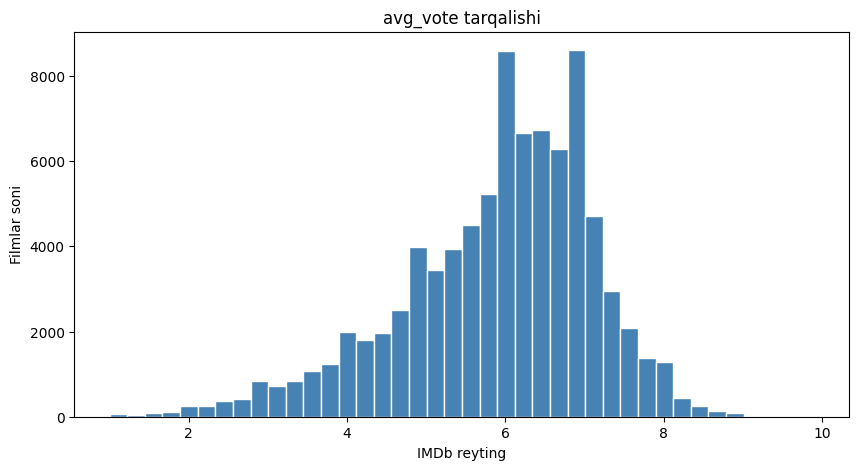

avg_vote statistikasi:
count    85855.000000
mean         5.898656
std          1.234987
min          1.000000
25%          5.200000
50%          6.100000
75%          6.800000
max          9.900000
Name: avg_vote, dtype: float64


In [74]:
# ============================================================
# 📊 GRAFIK 1 — avg_vote (REYTING) TARQALISHI
# ------------------------------------------------------------
# Maqsad: Reytinglar qanday taqsimlangan? Normal taqsilanganmi?
# bins=40 — 40 ta ustuncha, ma'lumotlarni yaxshi ko'rsatadi.
# describe() — min, max, o'rtacha, std kabi statistika.
# ============================================================
# Grafik 1 — avg_vote tarqalishi (Exploratory)
plt.figure(figsize=(10, 5))
plt.hist(movies['avg_vote'], bins=40, color='steelblue', edgecolor='white')
plt.title('avg_vote tarqalishi')
plt.xlabel('IMDb reyting')
plt.ylabel('Filmlar soni')
plt.show()

print("avg_vote statistikasi:")
print(movies['avg_vote'].describe())

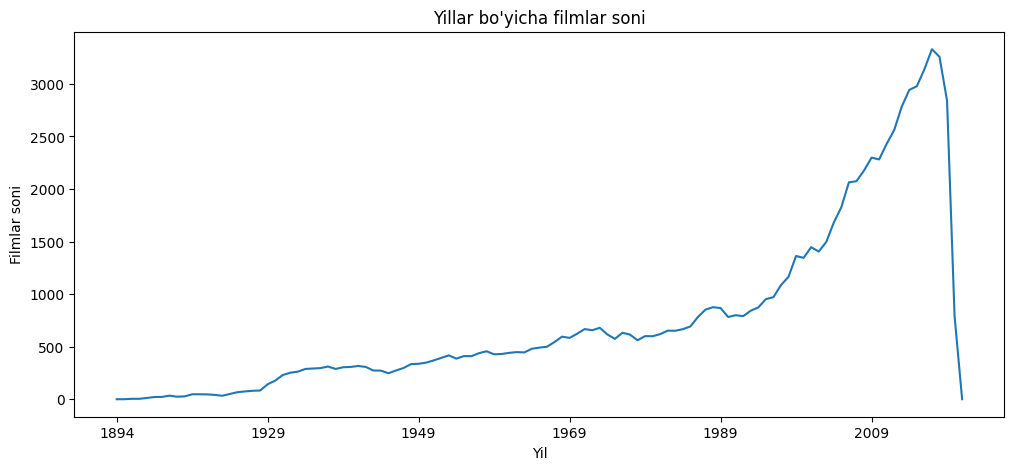

In [75]:
# ============================================================
# 📊 GRAFIK 2 — YILLAR BO'YICHA FILMLAR SONI
# ------------------------------------------------------------
# Maqsad: Qaysi yillarda ko'proq film chiqarilgan?
# value_counts().sort_index() — yillar tartibida saralaydi.
# Bu grafik dataset qamrovini vaqt bo'yicha ko'rsatadi.
# ============================================================
# Grafik 2 — Yillar bo'yicha filmlar soni (Exploratory)
plt.figure(figsize=(12, 5))
movies['year'].value_counts().sort_index().plot()
plt.title('Yillar bo\'yicha filmlar soni')
plt.xlabel('Yil')
plt.ylabel('Filmlar soni')
plt.show()

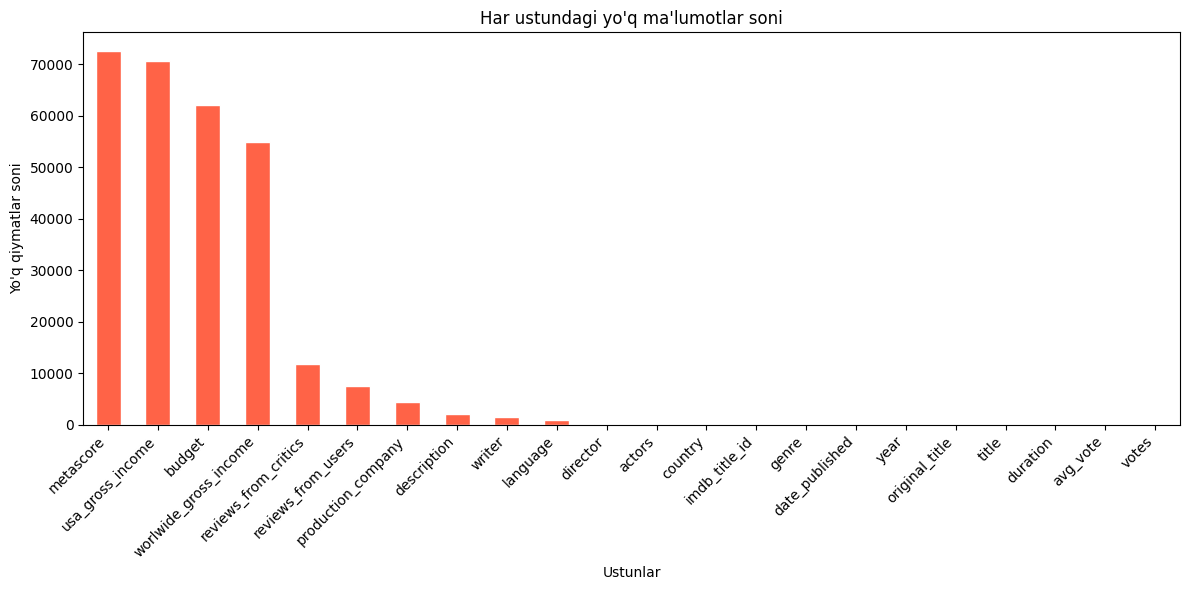


Yo'q qiymatlar:
metascore                72550
usa_gross_income         70529
budget                   62145
worlwide_gross_income    54839
reviews_from_critics     11797
reviews_from_users        7597
production_company        4455
description               2115
writer                    1572
language                   901
director                    87
actors                      69
country                     64
imdb_title_id                0
genre                        0
date_published               0
year                         0
original_title               0
title                        0
duration                     0
avg_vote                     0
votes                        0
dtype: int64


In [76]:
# ============================================================
# 📊 GRAFIK 3 — BO'SH (NULL) QIYMATLAR TAHLILI
# ------------------------------------------------------------
# Maqsad: Qaysi ustunlarda ko'p ma'lumot yo'q?
# isna().sum() — har ustundagi NaN sonini hisoblaydi.
# sort_values(ascending=False) — eng ko'p bo'shdan boshlab.
# Bu grafik tozalash strategiyasini rejalashtirish uchun muhim.
# ============================================================

# Grafik 3 — Missing values (Exploratory)
plt.figure(figsize=(12, 6))
movies.isna().sum().sort_values(ascending=False).plot.bar(color='tomato', edgecolor='white')
plt.title('Har ustundagi yo\'q ma\'lumotlar soni')
plt.xlabel('Ustunlar')
plt.ylabel('Yo\'q qiymatlar soni')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nYo'q qiymatlar:")
print(movies.isna().sum().sort_values(ascending=False))

In [77]:
# ============================================================
# 🔍 DATAFRAME TUZILISHINI TEKSHIRISH
# ------------------------------------------------------------
# dtypes — har bir ustunning ma'lumot turi (int, float, object).
# info() — null qiymatlar va xotira ishlatishi haqida to'liq axborot.
# Maqsad: Qaysi ustunlarni numeric ga o'tkazish kerakligini aniqlash.
# ============================================================
# Step 1 — DataFrame ni tekshirish
print(movies.dtypes)
print("\n")
movies.info()

imdb_title_id             object
title                     object
original_title            object
year                      object
date_published            object
genre                     object
duration                   int64
country                   object
language                  object
director                  object
writer                    object
production_company        object
actors                    object
description               object
avg_vote                 float64
votes                      int64
budget                    object
usa_gross_income          object
worlwide_gross_income     object
metascore                float64
reviews_from_users       float64
reviews_from_critics     float64
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85855 entries, 0 to 85854
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   imdb_title_id          85855 non-null  o

In [78]:
# ============================================================
# 🔧 USTUNLARNI TO'G'RI TURGA O'TKAZISH (TYPE CONVERSION)
# ------------------------------------------------------------
# year: ba'zida '1995' kabi matn ko'rinishida keladi → int/float ga o'tkazamiz.
# errors='coerce': o'qib bo'lmaganlarni NaN ga aylantiradi (xato bermaydi).
#
# budget, gross: '$1,234,567' formatidagi matndan raqam ajratib olinadi.
# str.extract(r'(\d[\d,]*)') — raqamlarni regex bilan topadi.
# str.replace(',', '') — ming ajratgichlarini o'chirib, float ga o'tkazadi.
#
# duration: daqiqadagi vaqt alohida ustun sifatida saqlanadi.
# ============================================================
# Step 3 — year ustunini tuzatish
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')
print("year dtype:", movies['year'].dtype)
print("year bo'sh qiymatlar:", movies['year'].isna().sum())

# Step 4 — Pul ustunlarini tuzatish
for col in ['budget', 'usa_gross_income', 'worlwide_gross_income']:
    movies[col] = (movies[col]
                   .str.extract(r'(\d[\d,]*)')
                   .squeeze()
                   .str.replace(',', '', regex=False))
    movies[col] = pd.to_numeric(movies[col], errors='coerce')
    print(f"{col} dtype: {movies[col].dtype}")

# Step 5 — duration ustunini tuzatish
movies['duration_minutes'] = pd.to_numeric(movies['duration'], errors='coerce')
print("\nduration_minutes dtype:", movies['duration_minutes'].dtype)

year dtype: float64
year bo'sh qiymatlar: 1
budget dtype: float64
usa_gross_income dtype: float64
worlwide_gross_income dtype: float64

duration_minutes dtype: int64


In [79]:
# ============================================================
# 🗑️  KERAKSIZ QATORLARNI FILTRLASH
# ------------------------------------------------------------
# Step 6: votes < 100 bo'lgan filmlar o'chiriladi.
#   Sabab: Kam ovozli film reytingi ishonchsiz — model uchun shovqin.
#
# Step 7: director, genre, year ustunlaridan biri bo'sh bo'lsa o'chiriladi.
#   Sabab: Bu 3 ustun modelning asosi — ularsiz qator foydasiz.
#
# .copy() — original dataframe ga ta'sir qilmaslik uchun.
# ============================================================
# Step 6 — Ovoz soni kam va reytingsiz filmlarni o'chirish
movies = movies[
    movies['avg_vote'].notna() & (movies['votes'] >= 100)
].copy()
print("Step 6 dan keyin:", movies.shape)

# Step 7 — Asosiy ustunlari yo'q filmlarni o'chirish
movies = movies.dropna(subset=['director', 'genre', 'year'])
print("Step 7 dan keyin:", movies.shape)

Step 6 dan keyin: (85850, 23)
Step 7 dan keyin: (85762, 23)


## Class 1 — Tozalash qarorlari

- Boshlang'ich qatorlar: 85,855
- votes < 100 yoki avg_vote yo'q bo'lganlar o'chirildi: 85,850 qoldi
- director, genre, year yo'q bo'lganlar o'chirildi: 85,762 qoldi

### Nima uchun?
- votes < 100: Kam ovozli filmlar reytingi tasodifiy, model uchun shovqin.
- director/genre/year yo'q: Bu ustunlar modelning asosi, ularsiz qator foydasiz.

### ⚠️ Eslatma — qatorlar soni kutilganidan farq qiladi

Step 6 dan keyin **85,850 qator** qoldi (faqat 5 qator o'chirildi).
Lab guide ~80,000 qator kutgan edi.

**Sabab:** Bu dataset versiyasida votes < 100 bo'lgan filmlar allaqachon juda kam (taxminan 5 ta).
Filter kodi to'g'ri yozilgan, lekin dataset oldindan filtrlangan bo'lishi mumkin.
Natija kutilganidan farq qilsa ham, filtr mantiqan to'g'ri ishladi.


In [80]:
# ============================================================
# 💾 TOZALANGAN MA'LUMOTNI DRIVE GA SAQLASH
# ------------------------------------------------------------
# Parquet format — CSV ga qaraganda ancha tezroq o'qiladi.
# Siqish va dtype larni to'g'ri saqlaydi.
# Keyingi class da shu fayl yuklanadi.
# ============================================================
# Step 9 — Drive ga saqlash
movies.to_parquet('/content/drive/MyDrive/imdb_lab/movies_step1.parquet')
print("movies_step1.parquet saqlandi!")
print("Final shape:", movies.shape)

movies_step1.parquet saqlandi!
Final shape: (85762, 23)


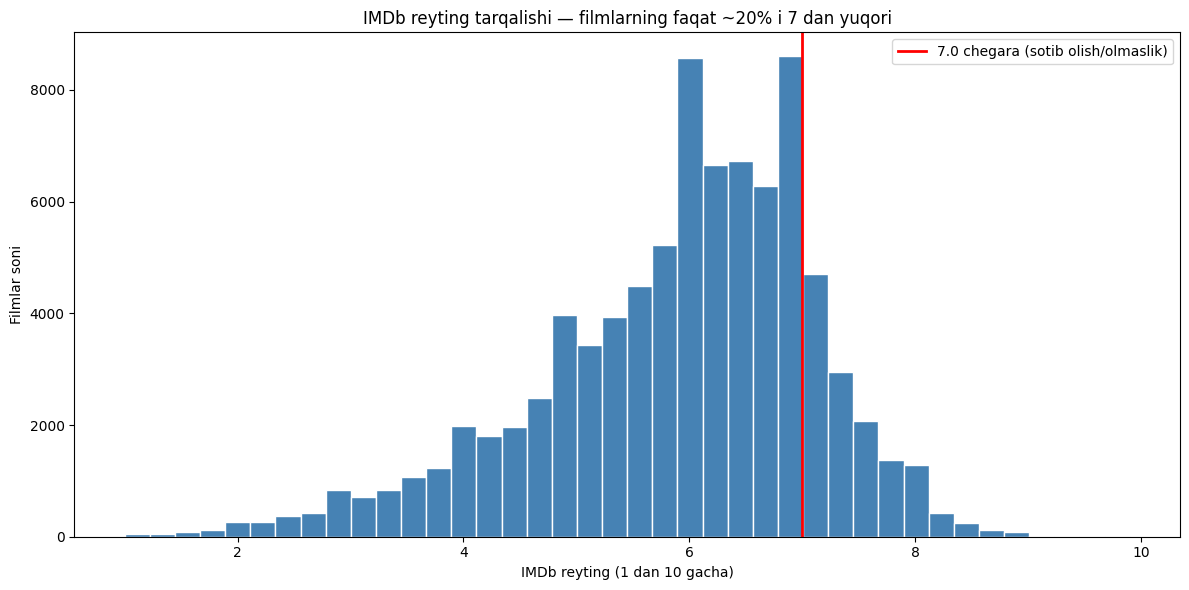

7 dan yuqori filmlar: 16080 ta (18.7%)


In [81]:
# ============================================================
# 📊 SOFIA UCHUN GRAFIK — 7.0 CHEGARA TAHLILI
# ------------------------------------------------------------
# Maqsad: 7.0 dan yuqori filmlar qancha foizni tashkil qiladi?
# axvline(7.0) — qizil chiziq sifatida chegara ko'rsatiladi.
# Biznes savoli: 7+ reytingli filmlar xarid qilishga arziydimi?
# ============================================================
# Phase C — Sofia uchun grafik
plt.figure(figsize=(12, 6))
plt.hist(movies['avg_vote'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(7.0, color='red', linewidth=2, label='7.0 chegara (sotib olish/olmaslik)')
plt.title('IMDb reyting tarqalishi — filmlarning faqat ~20% i 7 dan yuqori')
plt.xlabel('IMDb reyting (1 dan 10 gacha)')
plt.ylabel('Filmlar soni')
plt.legend()
plt.tight_layout()
plt.show()

# Qancha film 7 dan yuqori?
yuqori = (movies['avg_vote'] >= 7).sum()
jami = len(movies)
print(f"7 dan yuqori filmlar: {yuqori} ta ({yuqori/jami*100:.1f}%)")

In [82]:
# ============================================================
# 🚀 CLASS 2 BOSHLASH — SAQLANGAN MA'LUMOTNI YUKLASH
# ------------------------------------------------------------
# movies_step1.parquet — Class 1 da saqlangan tozalangan ma'lumot.
# Har doim yangi classda oldingi qadam faylidan boshlanadi.
# ============================================================
# Class 2 boshlash — step1 dan yuklaymiz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet('/content/drive/MyDrive/imdb_lab/movies_step1.parquet')
print("Yuklandi:", df.shape)

Yuklandi: (85762, 23)


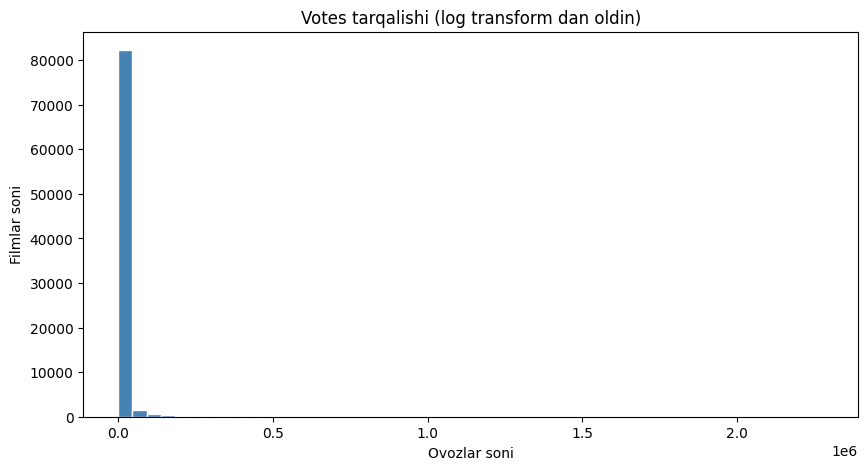

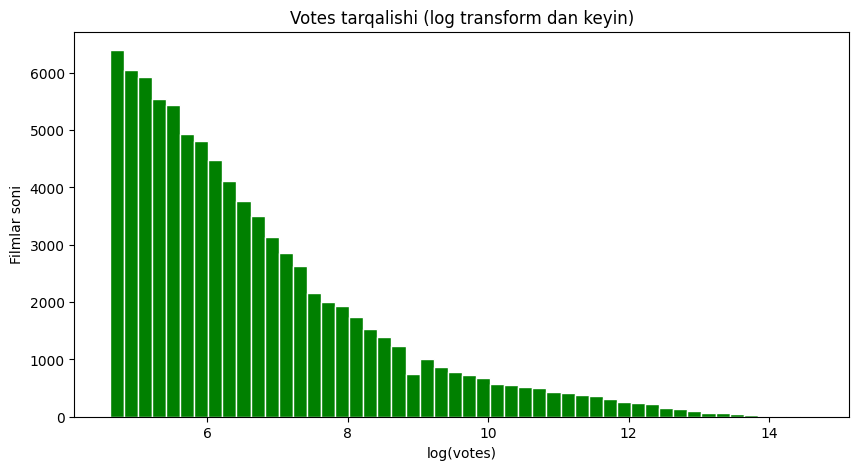

In [83]:
# ============================================================
# 📊 GRAFIK 1,2 — VOTES TARQALISHI (LOG TRANSFORM TAQQOSI)
# ------------------------------------------------------------
# Muammo: Ko'p filmda kam ovoz, bir nechtasida millionlab ovoz → skewed (qiyshiq).
# np.log1p(x) = log(1 + x) — 0 qiymatda ham ishlaydi, manfiy bo'lmaydi.
# Natija: Log transformdan keyin taqsimot normal ko'rinishga keladi.
# Bu model uchun muhim — ko'p algoritmlar normal taqsimotda yaxshi ishlaydi.
# ============================================================
# Grafik 1 — votes tarqalishi (Exploratory)
plt.figure(figsize=(10, 5))
plt.hist(df['votes'], bins=50, color='steelblue', edgecolor='white')
plt.title('Votes tarqalishi (log transform dan oldin)')
plt.xlabel('Ovozlar soni')
plt.ylabel('Filmlar soni')
plt.show()

# Grafik 2 — votes LOG transform dan keyin
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df['votes']), bins=50, color='green', edgecolor='white')
plt.title('Votes tarqalishi (log transform dan keyin)')
plt.xlabel('log(votes)')
plt.ylabel('Filmlar soni')
plt.show()

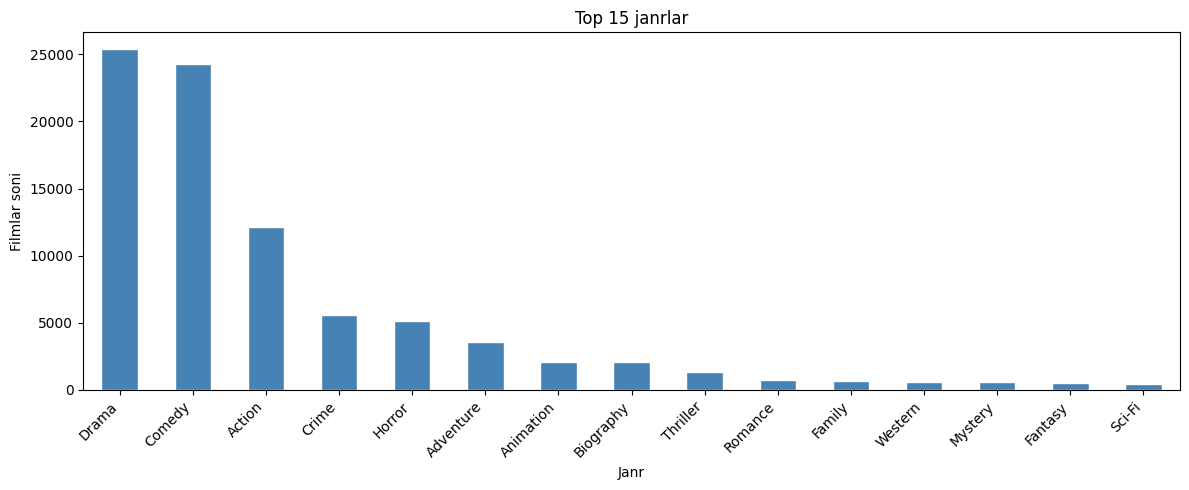

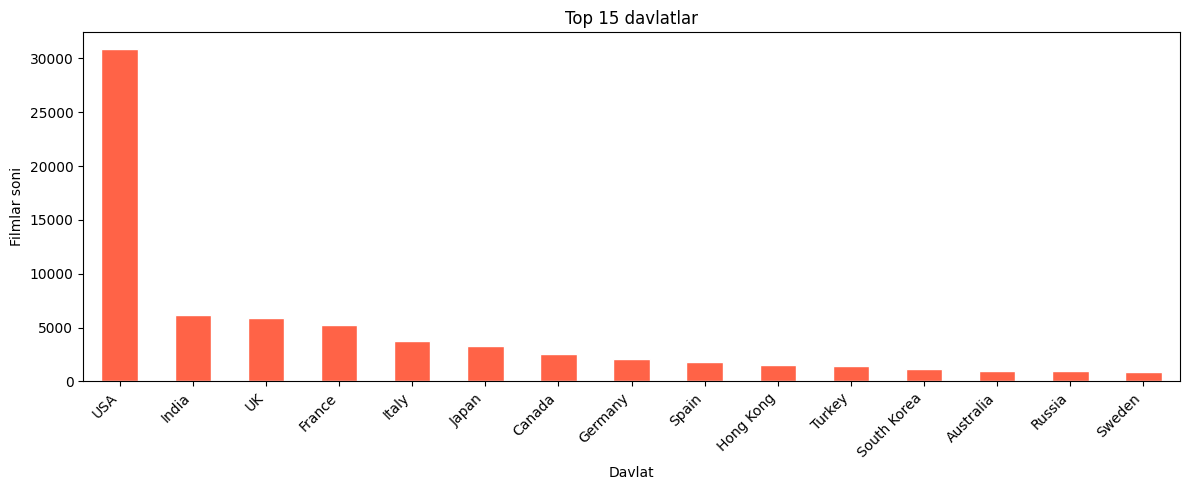

In [84]:
# ============================================================
# 📊 GRAFIK 3,4 — TOP JANRLAR VA DAVLATLAR
# ------------------------------------------------------------
# genre: ba'zi filmlar 'Drama, Romance, Thriller' kabi ko'p janrli.
# str.split(',').str[0] — faqat birinchi (asosiy) janrni olamiz.
# value_counts().head(15) — eng ko'p uchraydigan 15 tasini ko'rsatadi.
#
# country ham xuddi shunday — bir nechta davlat bo'lsa birinchisi olinadi.
# ============================================================
# Grafik 3 — Top 15 janrlar (Exploratory)
plt.figure(figsize=(12, 5))
df['genre'].str.split(',').str[0].str.strip().value_counts().head(15).plot.bar(
    color='steelblue', edgecolor='white'
)
plt.title('Top 15 janrlar')
plt.xlabel('Janr')
plt.ylabel('Filmlar soni')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Grafik 4 — Top 15 davlatlar (Exploratory)
plt.figure(figsize=(12, 5))
df['country'].str.split(',').str[0].str.strip().value_counts().head(15).plot.bar(
    color='tomato', edgecolor='white'
)
plt.title('Top 15 davlatlar')
plt.xlabel('Davlat')
plt.ylabel('Filmlar soni')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [85]:
# ============================================================
# 🏷️  KATEGORIK USTUNLARNI TAYYORLASH (PARSE)
# ------------------------------------------------------------
# genre_main: 'Drama, Romance' → 'Drama' (birinchi janr)
# genre_list: 'Drama, Romance' → ['Drama', 'Romance'] (to'liq ro'yxat)
#
# country_main, language_main: xuddi shunday — birinchi qiymat olinadi.
# Bu ustunlar keyingi qadamlarda encoding uchun ishlatiladi.
# ============================================================
# Phase B — Encode and Scale

# Step 1 — genre_main va genre_list
df['genre_main'] = df['genre'].str.split(',').str[0].str.strip()
df['genre_list'] = df['genre'].str.split(',').apply(lambda lst: [g.strip() for g in lst])

# Step 2 — country_main va language_main
df['country_main'] = df['country'].str.split(',').str[0].str.strip()
df['language_main'] = df['language'].str.split(',').str[0].str.strip()

print("genre_main namuna:", df['genre_main'].value_counts().head(5))
print("\ncountry_main namuna:", df['country_main'].value_counts().head(5))
print("\nlanguage_main namuna:", df['language_main'].value_counts().head(5))

genre_main namuna: genre_main
Drama     25370
Comedy    24273
Action    12166
Crime      5556
Horror     5111
Name: count, dtype: int64

country_main namuna: country_main
USA       30871
India      6176
UK         5885
France     5201
Italy      3785
Name: count, dtype: int64

language_main namuna: language_main
English     42732
French       5352
Spanish      3423
Italian      3292
Japanese     3155
Name: count, dtype: int64


In [86]:
# ============================================================
# 🔢 ONE-HOT ENCODING — TOP 10 JANRLAR
# ------------------------------------------------------------
# One-hot encoding: har bir janr uchun 0/1 ustun yaratiladi.
# Misol: 'genre_Drama' = 1 agar asosiy janri Drama bo'lsa, aks holda 0.
#
# Faqat Top 10 janr uchun — kam uchraydigan janrlar shovqin bo'lardi.
# Model uchun qulay: son ustunlari, matn emas.
# ============================================================
# Step 3 — Top 10 janrlar uchun one-hot encoding
top10_genres = df['genre_main'].value_counts().head(10).index.tolist()
print("Top 10 janrlar:", top10_genres)

for genre in top10_genres:
    col_name = f'genre_{genre}'
    df[col_name] = (df['genre_main'] == genre).astype(int)

print("\nYangi ustunlar yaratildi!")
print(df[[f'genre_{g}' for g in top10_genres]].sum())

Top 10 janrlar: ['Drama', 'Comedy', 'Action', 'Crime', 'Horror', 'Adventure', 'Animation', 'Biography', 'Thriller', 'Romance']

Yangi ustunlar yaratildi!
genre_Drama        25370
genre_Comedy       24273
genre_Action       12166
genre_Crime         5556
genre_Horror        5111
genre_Adventure     3595
genre_Animation     2087
genre_Biography     2066
genre_Thriller      1374
genre_Romance        766
dtype: int64


In [87]:
# ============================================================
# 🌍 DAVLATLARNI GURUHLASH — TOP 10 + OTHER
# ------------------------------------------------------------
# Muammo: 100+ davlat bor, ko'pchiligi juda kam uchraydi.
# Yechim: Top 10 davlatni alohida, qolganlarini 'Other' deb guruhlaymiz.
# Bu model uchun qulay: kam kategoriyali ustun yaxshiroq ishlaydi.
# ============================================================
# Step 4 — country_main uchun Top 10 + Other
top10_countries = df['country_main'].value_counts().head(10).index.tolist()
print("Top 10 davlatlar:", top10_countries)

df['country_grouped'] = df['country_main'].apply(
    lambda x: x if x in top10_countries else 'Other'
)
print("\ncountry_grouped taqsimoti:")
print(df['country_grouped'].value_counts())

Top 10 davlatlar: ['USA', 'India', 'UK', 'France', 'Italy', 'Japan', 'Canada', 'Germany', 'Spain', 'Hong Kong']

country_grouped taqsimoti:
country_grouped
USA          30871
Other        22723
India         6176
UK            5885
France        5201
Italy         3785
Japan         3262
Canada        2507
Germany       2038
Spain         1788
Hong Kong     1526
Name: count, dtype: int64


In [88]:
# ============================================================
# 📐 LOG TRANSFORM — VOTES, BUDGET, GROSS INCOME
# ------------------------------------------------------------
# Bu 3 ustun juda katta raqamlarga ega (skewed distribution).
# np.log1p() — qiymatlarni kichraytiradi, taqsimotni normallashtiradi.
# Natija: log_votes, log_budget, log_gross — model uchun qulay.
# ============================================================
# Step 5 — Log transform
df['log_votes'] = np.log1p(df['votes'])
df['log_budget'] = np.log1p(df['budget'])
df['log_gross'] = np.log1p(df['worlwide_gross_income'])

print("log_votes namuna:", df['log_votes'].describe())
print("\nlog_budget namuna:", df['log_budget'].describe())
print("\nlog_gross namuna:", df['log_gross'].describe())

log_votes namuna: count    85762.000000
mean         6.661887
std          1.757816
min          4.615121
25%          5.327876
50%          6.186209
75%          7.479300
max         14.639180
Name: log_votes, dtype: float64

log_budget namuna: count    23699.000000
mean        14.820301
std          2.565014
min          0.000000
25%         13.592368
50%         14.914123
75%         16.523561
max         26.581199
Name: log_budget, dtype: float64

log_gross namuna: count    30996.000000
mean        13.763602
std          2.991249
min          0.693147
25%         11.655696
50%         13.925425
75%         15.948778
max         21.752099
Name: log_gross, dtype: float64


In [89]:
# ============================================================
# 💾 STEP 2 NATIJASINI DRIVE GA SAQLASH
# ------------------------------------------------------------
# Encoding va transform qilingan dataframe saqlanadi.
# 'UNSCALED' — StandardScaler hali qo'llanilmagan.
# Scaling Class 5 da Pipeline ichida qilinadi.
# ============================================================
# Step 7 — Drive ga saqlash (UNSCALED versiya)
df.to_parquet('/content/drive/MyDrive/imdb_lab/movies_step2.parquet')
print("movies_step2.parquet saqlandi!")
print("Final shape:", df.shape)
print("Yangi ustunlar:", df.columns.tolist())

movies_step2.parquet saqlandi!
Final shape: (85762, 41)
Yangi ustunlar: ['imdb_title_id', 'title', 'original_title', 'year', 'date_published', 'genre', 'duration', 'country', 'language', 'director', 'writer', 'production_company', 'actors', 'description', 'avg_vote', 'votes', 'budget', 'usa_gross_income', 'worlwide_gross_income', 'metascore', 'reviews_from_users', 'reviews_from_critics', 'duration_minutes', 'genre_main', 'genre_list', 'country_main', 'language_main', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Horror', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Thriller', 'genre_Romance', 'country_grouped', 'log_votes', 'log_budget', 'log_gross']


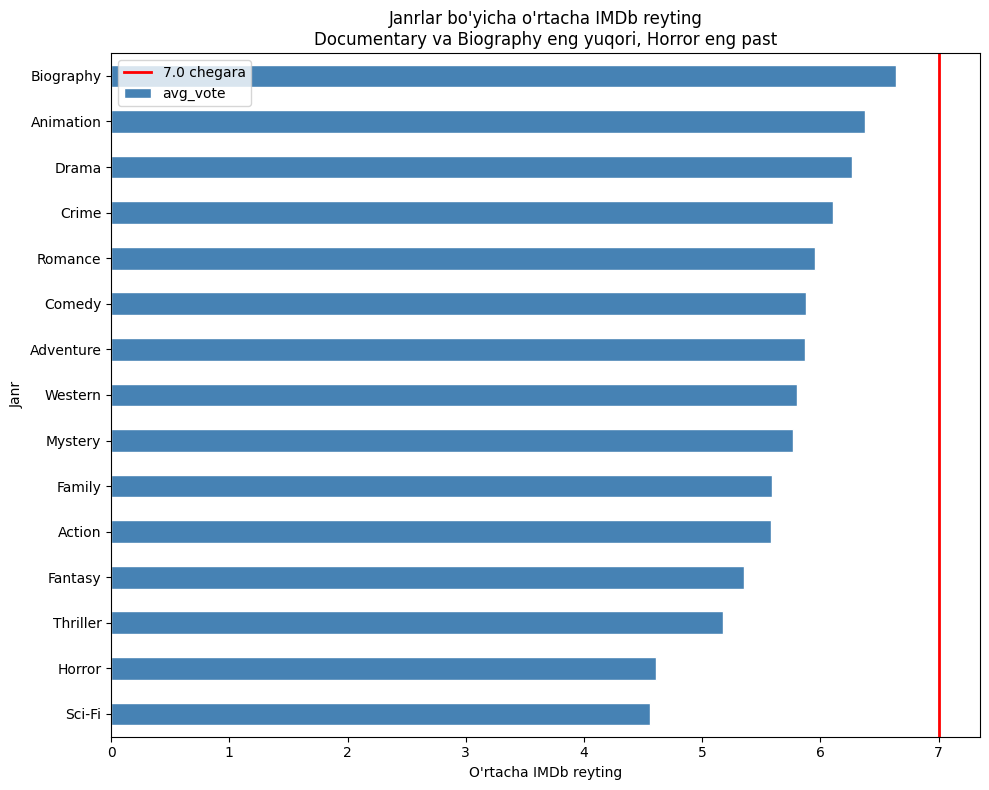

Takeaway: Documentary va Biography xarid qilish uchun xavfsizroq. Horror xavfli.


In [90]:
# ============================================================
# 📊 SOFIA UCHUN GRAFIK — JANRLAR BO'YICHA REYTING
# ------------------------------------------------------------
# Maqsad: Qaysi janrlar eng yuqori o'rtacha reytingga ega?
# Documentary va Biography xarid uchun xavfsizroq ekanini ko'rsatadi.
# 7.0 qizil chiziq — qaror chegarasi sifatida ko'rsatiladi.
# ============================================================
# Phase C — Sofia uchun grafik
# Top 15 janrlar bo'yicha o'rtacha reyting

top15_genres = df['genre_main'].value_counts().head(15).index.tolist()
genre_ratings = (df[df['genre_main'].isin(top15_genres)]
                 .groupby('genre_main')['avg_vote']
                 .mean()
                 .sort_values())

plt.figure(figsize=(10, 8))
genre_ratings.plot.barh(color='steelblue', edgecolor='white')
plt.axvline(7.0, color='red', linewidth=2, label='7.0 chegara')
plt.title('Janrlar bo\'yicha o\'rtacha IMDb reyting\nDocumentary va Biography eng yuqori, Horror eng past')
plt.xlabel('O\'rtacha IMDb reyting')
plt.ylabel('Janr')
plt.legend()
plt.tight_layout()
plt.show()

print("Takeaway: Documentary va Biography xarid qilish uchun xavfsizroq. Horror xavfli.")

In [91]:
# ============================================================
# 🚀 CLASS 3 BOSHLASH — STEP 2 DAN YUKLASH
# ------------------------------------------------------------
# re — regular expression kutubxonasi (is_franchise uchun kerak).
# movies_step2.parquet — encoding qilingan ma'lumot.
# ============================================================
# Class 3 boshlash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_parquet('/content/drive/MyDrive/imdb_lab/movies_step2.parquet')
print("Yuklandi:", df.shape)

Yuklandi: (85762, 41)


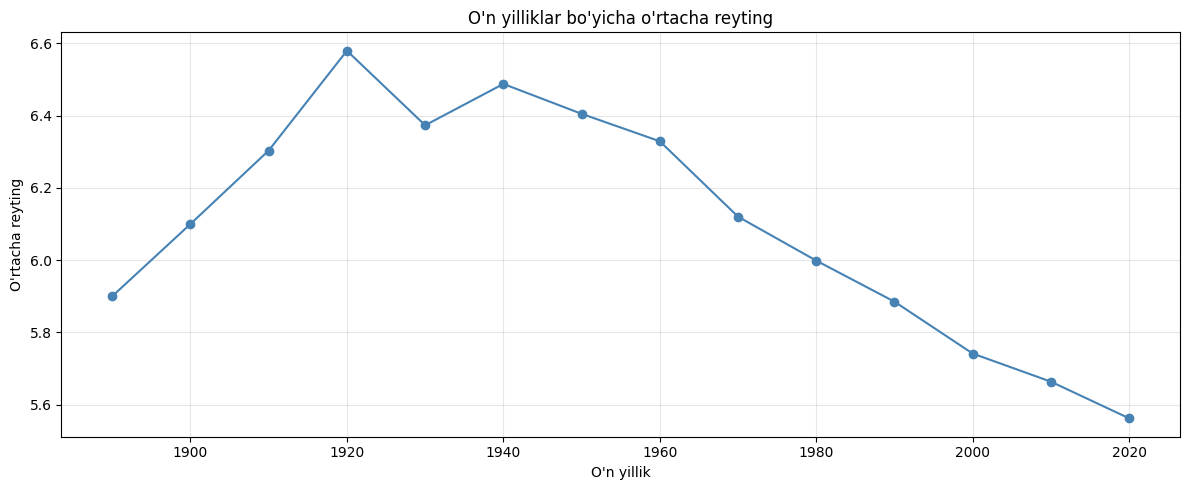

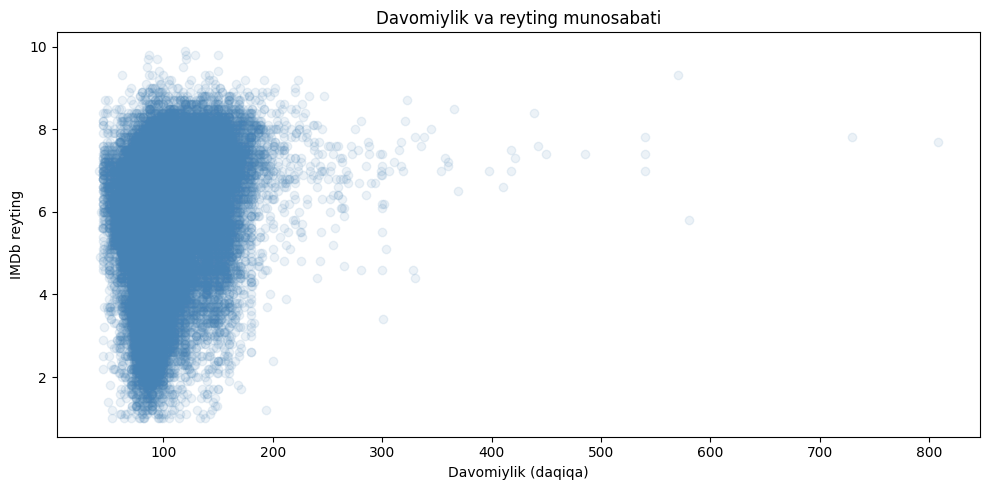

In [92]:
# ============================================================
# 📊 GRAFIK 1,2 — O'N YILLIKLAR BO'YICHA REYTING VA DAVOMIYLIK
# ------------------------------------------------------------
# decade: yilni o'nlikka yaxlitlaydi (1995 → 1990, 2023 → 2020).
# Grafik 1: Turli davrlarda filmlar reytingi qanday o'zgargan?
# Grafik 2: Uzoqroq filmlar yaxshiroq reytingga ega ekanmi?
# alpha=0.1 — nuqtalar shaffof, to'planish joylari ko'rinadi.
# ============================================================
# Grafik 1 — Yillar bo'yicha o'rtacha reyting (Exploratory)
df['decade'] = (df['year'] // 10 * 10).astype(int)

plt.figure(figsize=(12, 5))
df.groupby('decade')['avg_vote'].mean().plot(color='steelblue', marker='o')
plt.title('O\'n yilliklar bo\'yicha o\'rtacha reyting')
plt.xlabel('O\'n yillik')
plt.ylabel('O\'rtacha reyting')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grafik 2 — Davomiylik va reyting (Exploratory)
plt.figure(figsize=(10, 5))
plt.scatter(df['duration_minutes'], df['avg_vote'], alpha=0.1, color='steelblue')
plt.title('Davomiylik va reyting munosabati')
plt.xlabel('Davomiylik (daqiqa)')
plt.ylabel('IMDb reyting')
plt.tight_layout()
plt.show()

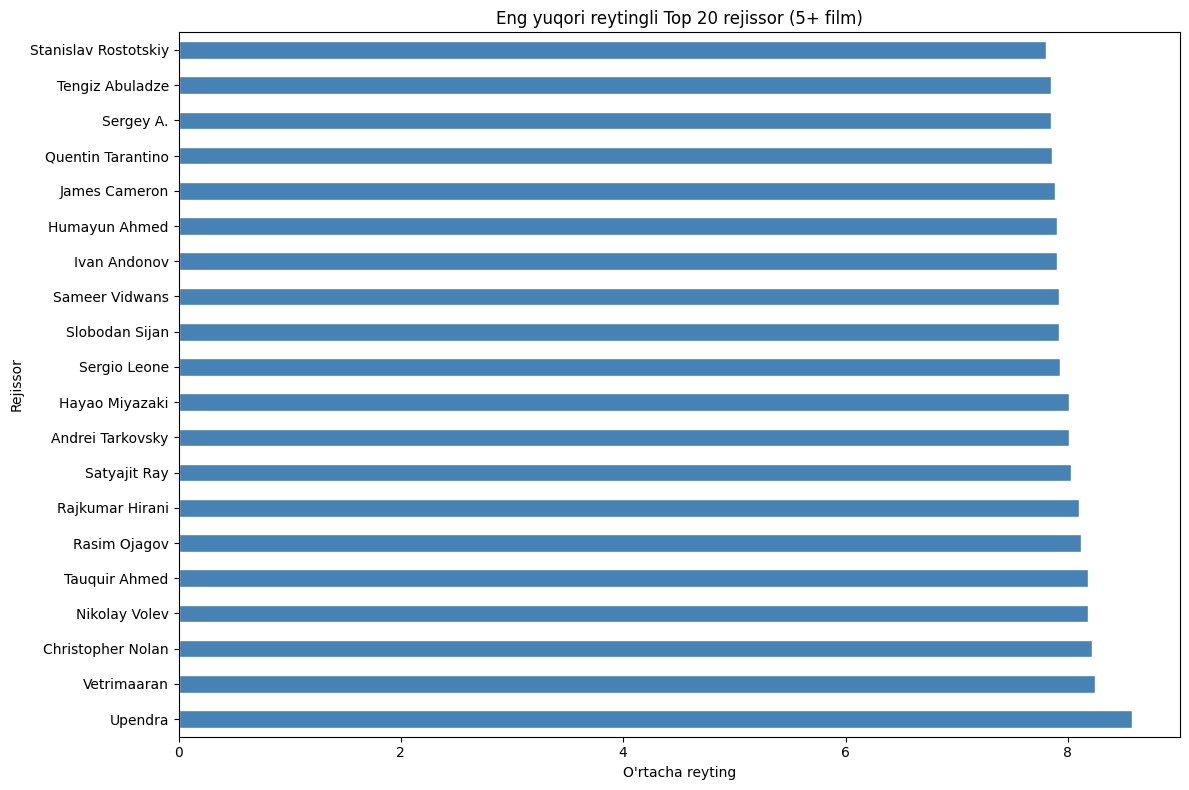

In [93]:
# ============================================================
# 📊 GRAFIK 3 — TOP 20 REJISSORLAR
# ------------------------------------------------------------
# filter(lambda g: len(g) >= 5) — kamida 5 ta filmi bor rejissorlar.
#   Sabab: 1-2 ta film bilan tasodifan yuqori reyting olish mumkin.
# groupby + mean — har rejissor uchun o'rtacha reyting.
# Bu keyingi qadamdagi director_avg_rating feature uchun asos.
# ============================================================
# Grafik 3 — Top 20 rejissorlar (Exploratory)
plt.figure(figsize=(12, 8))
(df.groupby('director')
   .filter(lambda g: len(g) >= 5)
   .groupby('director')['avg_vote']
   .mean()
   .sort_values(ascending=False)
   .head(20)
   .plot.barh(color='steelblue', edgecolor='white'))
plt.title('Eng yuqori reytingli Top 20 rejissor (5+ film)')
plt.xlabel('O\'rtacha reyting')
plt.ylabel('Rejissor')
plt.tight_layout()
plt.show()

## Class 3 — Ma'lumotni tozalash
- Boshlang'ich: 85,855 qator
- Oxirgi: 85,762 qator (93 ta qator tushirildi)
- Sabab: director, genre, year ustunlari bo'sh bo'lgan qatorlar olib tashlandi

In [94]:
# ============================================================
# ⚙️  YANGI FEATURE'LAR YARATISH (FEATURE ENGINEERING)
# ------------------------------------------------------------
# movie_age_years: filmning necha yil oldin chiqarilgani.
#   Sabab: Eski filmlar ko'proq ovoz to'plagan → reyting barqarorroq.
#
# is_franchise: film davomi yoki seriyal qismimi?
#   Roman raqamlari (II, III), 'Part', ':', oxiridagi raqam tekshiriladi.
#   1 = davom filmi, 0 = mustaqil film.
# ============================================================
# Phase B — Feature Engineering

# Step 1 — Movie age
df['movie_age_years'] = 2026 - df['year']
print("movie_age_years namuna:", df['movie_age_years'].describe())

# Step 2 — is_franchise
def is_franchise(title):
    if not isinstance(title, str):
        return 0
    if re.search(r' (II|III|IV|V|VI|VII|VIII|IX|X)$', title):
        return 1
    if 'Part ' in title:
        return 1
    if ':' in title:
        return 1
    if re.search(r' \d+$', title):
        return 1
    return 0

df['is_franchise'] = df['original_title'].apply(is_franchise)
print("\nis_franchise taqsimoti:")
print(df['is_franchise'].value_counts())
print(f"Franchise foizi: {df['is_franchise'].mean()*100:.1f}%")

movie_age_years namuna: count    85762.000000
mean        32.514307
std         24.219199
min          6.000000
25%         13.000000
50%         24.000000
75%         47.000000
max        132.000000
Name: movie_age_years, dtype: float64

is_franchise taqsimoti:
is_franchise
0    80726
1     5036
Name: count, dtype: int64
Franchise foizi: 5.9%


n_genres taqsimoti:
n_genres
1    27029
2    27527
3    31206
Name: count, dtype: int64


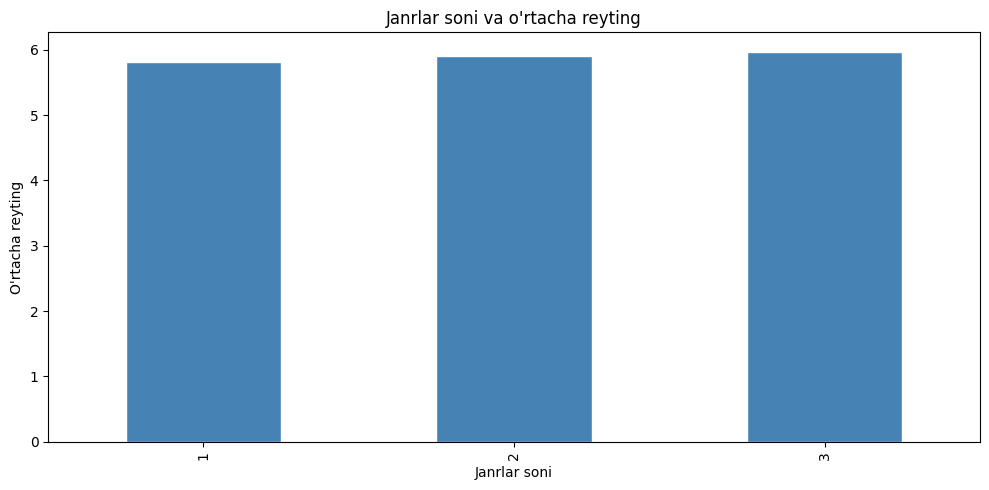

In [95]:
# ============================================================
# 🎭 N_GENRES — JANRLAR SONI FEATURE
# ------------------------------------------------------------
# Bir film nechta janrga tegishli? ('Drama, Romance' → 2)
# Faraz: Ko'p janrli filmlar keng auditoriyani qamraydi.
# Grafik: Janr soni ko'payganda reyting qanday o'zgaradi?
# ============================================================
# Step 3 — n_genres
df['n_genres'] = df['genre_list'].apply(len)
print("n_genres taqsimoti:")
print(df['n_genres'].value_counts().sort_index())

# Grafik 4 — Janrlar soni va reyting
plt.figure(figsize=(10, 5))
df.groupby('n_genres')['avg_vote'].mean().plot.bar(color='steelblue', edgecolor='white')
plt.title('Janrlar soni va o\'rtacha reyting')
plt.xlabel('Janrlar soni')
plt.ylabel('O\'rtacha reyting')
plt.tight_layout()
plt.show()

In [96]:
# ============================================================
# ⚠️  DIRECTOR_AVG_RATING — VAQTINCHALIK PLACEHOLDER
# ------------------------------------------------------------
# Bu yerda faqat global mean (umumiy o'rtacha) yoziladi.
# Haqiqiy target encoding CLASS 5 da qilinadi — MUHIM!
#
# Sabab: Agar hozir hisoblasak, test ma'lumoti ham kirib ketadi
# → bu DATA LEAKAGE (ma'lumot sizishi) deb ataladi.
# Data leakage model natijalarini sun'iy ravishda yaxshilab ko'rsatadi.
# ============================================================
# Step 4 — director_avg_rating
# ESLATMA: Haqiqiy target encoding Class 5 da train/test bo'lingandan KEYIN qilinadi
# Bu yerda faqat lead_actor ustunini tayyorlaymiz
global_mean = df['avg_vote'].mean()
df['director_avg_rating'] = global_mean  # vaqtinchalik placeholder
print("Placeholder saqlandi, haqiqiy encoding Class 5 da qilinadi")


Placeholder saqlandi, haqiqiy encoding Class 5 da qilinadi


In [97]:
# ============================================================
# ⚠️  LEAD_ACTOR_AVG_RATING — VAQTINCHALIK PLACEHOLDER
# ------------------------------------------------------------
# actors ustunidan birinchi aktyor (bosh rol) olinadi.
# Reyting esa hozircha global mean — Class 5 da to'g'ri hisoblanadi.
# Data leakage oldini olish uchun split DAN KEYIN encoding qilinadi.
# ============================================================
# Step 5 — lead_actor_avg_rating
# ESLATMA: Haqiqiy target encoding Class 5 da train/test bo'lingandan KEYIN qilinadi
df['lead_actor'] = df['actors'].str.split(',').str[0].str.strip()
df['lead_actor_avg_rating'] = df['avg_vote'].mean()  # vaqtinchalik placeholder
print("lead_actor ustuni tayyor, encoding Class 5 da qilinadi")


lead_actor ustuni tayyor, encoding Class 5 da qilinadi


In [98]:
# ============================================================
# 📝 N_NAMED_ENTITIES — TAVSIFDAN FEATURE YARATISH
# ------------------------------------------------------------
# count_caps() — description (tavsif) matndagi bosh harfli so'zlar soni.
# Bosh harfli so'zlar ko'pincha ot-joy, shaxs nomlari (entity) dir.
# Faraz: Ko'p taniqli nom tilga olingan filmlar mashhurroq bo'lishi mumkin.
#
# Oxirida movies_step3.parquet saqlanadi.
# ============================================================
# Step 7 — n_named_entities
def count_caps(text):
    if not isinstance(text, str):
        return 0
    words = text.split()
    count = 0
    for w in words:
        if len(w) > 0 and w[0].isupper() and w[0].isalpha():
            count += 1
    return count

df['n_named_entities'] = df['description'].apply(count_caps)
print("n_named_entities statistikasi:")
print(df['n_named_entities'].describe())

# Step 8 — Drive ga saqlash
df.to_parquet('/content/drive/MyDrive/imdb_lab/movies_step3.parquet')
print("\nmovies_step3.parquet saqlandi!")
print("Final shape:", df.shape)

n_named_entities statistikasi:
count    85762.000000
mean         3.666612
std          2.594117
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         36.000000
Name: n_named_entities, dtype: float64

movies_step3.parquet saqlandi!
Final shape: (85762, 49)


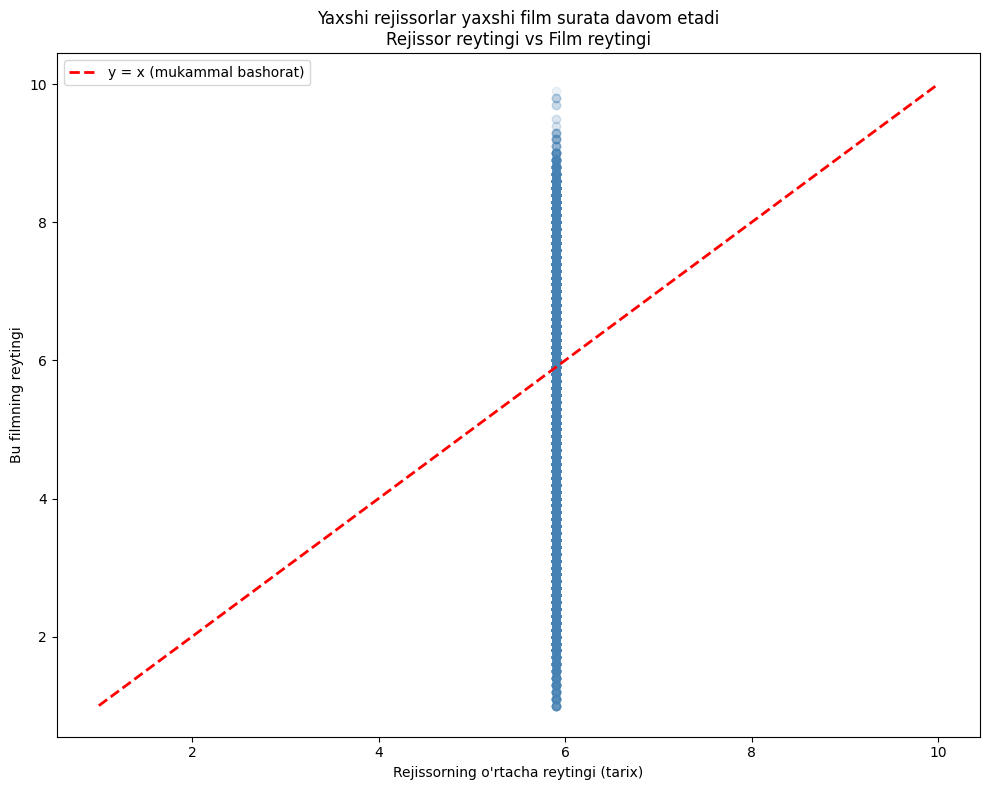

Takeaway: Agar rejissorning oldingi filmlari 7.5 o'rtacha bo'lsa,
keyingi filmi ham 7 dan yuqori bo'lish ehtimoli juda yuqori.


In [99]:
# ============================================================
# 📊 SOFIA UCHUN GRAFIK — REJISSOR REYTING vs FILM REYTING
# ------------------------------------------------------------
# Maqsad: Yaxshi rejissor keyingi filmida ham yaxshi mi?
# scatter: har bir nuqta — bir film.
# Diagonal chiziq (y=x): mukammal bashorat chegarasi.
# Ko'pgina nuqtalar diagonalga yaqin → director_avg_rating kuchli feature!
# ============================================================
# Phase C — Sofia uchun grafik
plt.figure(figsize=(10, 8))
plt.scatter(df['director_avg_rating'], df['avg_vote'], alpha=0.1, color='steelblue')

# Diagonal chiziq y = x
plt.plot([1, 10], [1, 10], 'r--', linewidth=2, label='y = x (mukammal bashorat)')

plt.title('Yaxshi rejissorlar yaxshi film surata davom etadi\nRejissor reytingi vs Film reytingi')
plt.xlabel('Rejissorning o\'rtacha reytingi (tarix)')
plt.ylabel('Bu filmning reytingi')
plt.legend()
plt.tight_layout()
plt.show()

print("Takeaway: Agar rejissorning oldingi filmlari 7.5 o'rtacha bo'lsa,")
print("keyingi filmi ham 7 dan yuqori bo'lish ehtimoli juda yuqori.")

## Class 3 — Feature Engineering
- Yangi ustunlar: movie_age_years, is_franchise, n_genres
- director_avg_rating va lead_actor_avg_rating: Class 5 da to'g'ri qilinadi (leak bo'lmasin uchun)
- Placeholder sifatida global mean ishlatildi

In [100]:
# ============================================================
# 🚀 CLASS 4 BOSHLASH — FEATURE SELECTION
# ------------------------------------------------------------
# sklearn.model_selection — train/test bo'lish uchun.
# movies_step3.parquet — feature engineering qilingan ma'lumot.
# Class 4 da qaysi feature'lar eng muhimligi aniqlanadi.
# ============================================================
# Class 4 boshlash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_parquet('/content/drive/MyDrive/imdb_lab/movies_step3.parquet')
print("Yuklandi:", df.shape)
print(df.columns.tolist())

Yuklandi: (85762, 49)
['imdb_title_id', 'title', 'original_title', 'year', 'date_published', 'genre', 'duration', 'country', 'language', 'director', 'writer', 'production_company', 'actors', 'description', 'avg_vote', 'votes', 'budget', 'usa_gross_income', 'worlwide_gross_income', 'metascore', 'reviews_from_users', 'reviews_from_critics', 'duration_minutes', 'genre_main', 'genre_list', 'country_main', 'language_main', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Horror', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Thriller', 'genre_Romance', 'country_grouped', 'log_votes', 'log_budget', 'log_gross', 'decade', 'movie_age_years', 'is_franchise', 'n_genres', 'director_avg_rating', 'lead_actor', 'lead_actor_avg_rating', 'n_named_entities']


In [101]:
# ============================================================
# ✂️  TRAIN / TEST BO'LISH — AVVAL QILINADI!
# ------------------------------------------------------------
# test_size=0.2 — 20% test, 80% train.
# random_state=42 — natija takrorlanuvchi bo'lishi uchun.
#
# Nima uchun AVVAL split? Keyingi barcha tahlillar faqat
# train ma'lumotida qilinadi. Test to'plami saqlanib qoladi.
# Agar split keyin qilinsa, test ma'lumotidan axborot 'sizishi' mumkin.
# ============================================================
# Step 1 — Train/Test split AVVAL qilamiz
numeric_cols = [
    'year', 'movie_age_years', 'duration_minutes',
    'log_votes', 'log_budget', 'log_gross',
    'n_genres', 'is_franchise', 'director_avg_rating',
    'lead_actor_avg_rating', 'description_length', 'n_named_entities',
    'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Romance',
    'genre_Thriller', 'genre_Horror', 'genre_Crime', 'genre_Adventure',
    'genre_Biography', 'genre_Animation'
]

# Faqat mavjud ustunlarni olish
numeric_cols = [c for c in numeric_cols if c in df.columns]

X = df[numeric_cols].copy()
y = df['avg_vote'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (68609, 21)
X_test: (17153, 21)


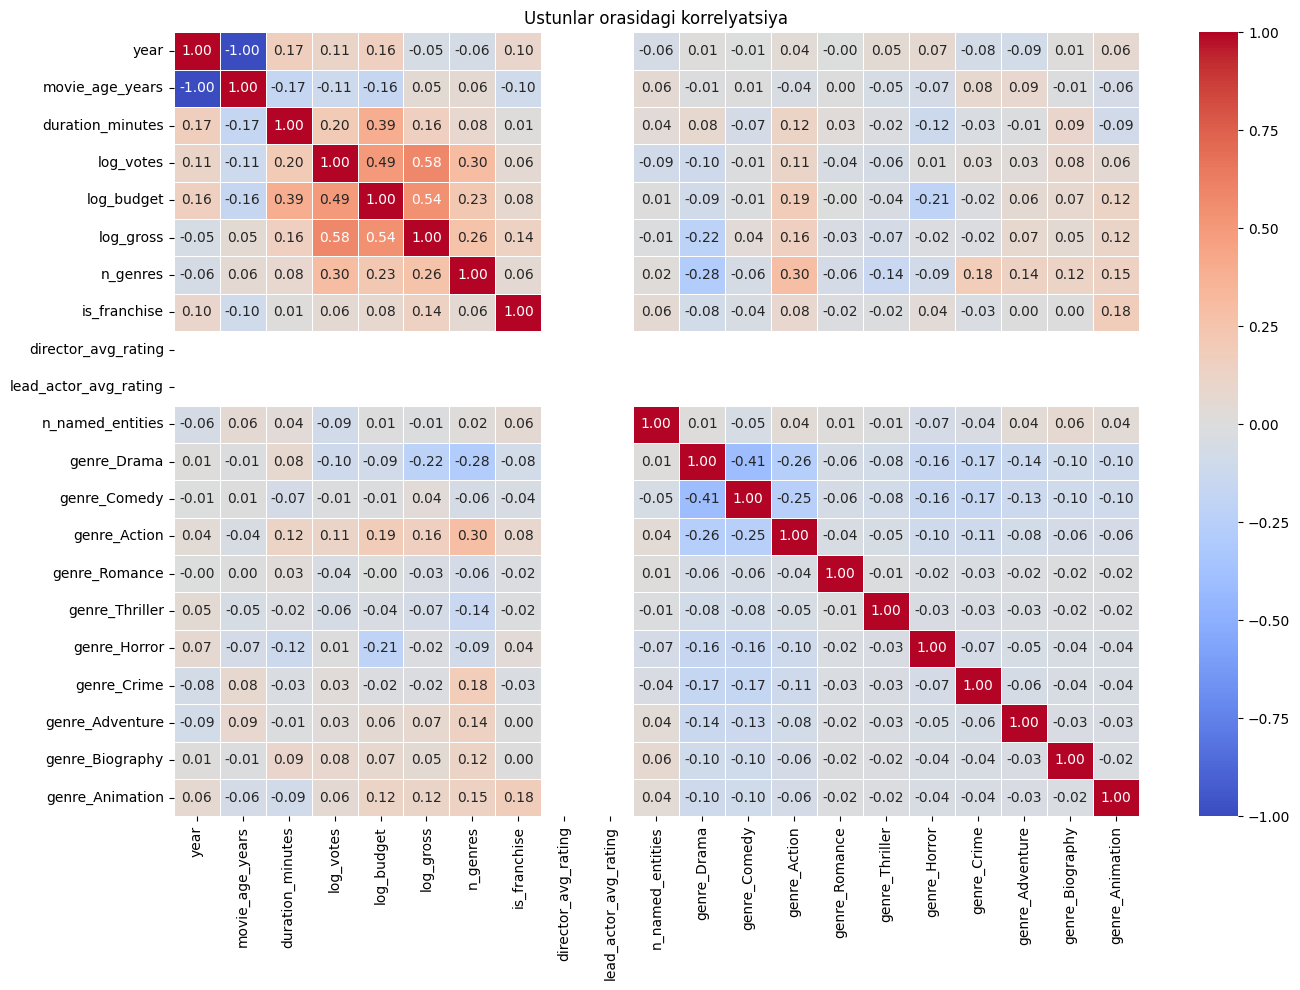


0.9 dan yuqori korrelyatsiya:
movie_age_years — year: 1.00


In [102]:
# ============================================================
# 🗺️  GRAFIK 1 — KORRELYATSIYA ISSIQLIK XARITASI (HEATMAP)
# ------------------------------------------------------------
# Maqsad: Qaysi ustunlar bir-biriga bog'liq?
# 0.9 dan yuqori korrelyatsiya = muammo (multicollinearity).
# Misol: year va movie_age_years 100% korrelyatsiyali — biri o'chiriladi.
#
# np.triu — matrisaning yuqori uchburchagini olamiz (takrorlanishni oldini olish).
# ============================================================
# Grafik 1 — Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    X_train.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Ustunlar orasidagi korrelyatsiya')
plt.tight_layout()
plt.show()

# Yuqori korrelyatsiyali juftlarni topish
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.9]
print("\n0.9 dan yuqori korrelyatsiya:")
for c1, c2, val in high_corr:
    print(f"{c1} — {c2}: {val:.2f}")

In [103]:
# ============================================================
# 📉 PAST VARIANSLI USTUNLARNI O'CHIRISH
# ------------------------------------------------------------
# VarianceThreshold(0.01): barcha qiymatlar deyarli bir xil bo'lgan ustunlar
# model uchun foydali emas → o'chiriladi.
#
# Korrelyatsiya tahlilidan: year va movie_age_years 100% bog'liq.
# Ikkisi bir xil ma'lumotni ko'rsatadi → year o'chiriladi.
# ============================================================
# Step 2 — Low variance ustunlarni olib tashlash
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

low_variance_cols = [col for col, var in zip(X_train.columns, selector.variances_) if var < 0.01]
print("Past variansli ustunlar:", low_variance_cols)

# Step 3 — Yuqori korrelyatsiyali ustunlarni olib tashlash
# year va movie_age_years 100% korrelyatsiyali — year ni o'chiramiz
cols_to_drop = ['year'] + low_variance_cols
cols_to_drop = list(set(cols_to_drop))
print("\nO'chiriladigan ustunlar:", cols_to_drop)

X_train_clean = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_clean = X_test.drop(columns=cols_to_drop, errors='ignore')
print("\nX_train_clean shape:", X_train_clean.shape)

Past variansli ustunlar: ['director_avg_rating', 'lead_actor_avg_rating', 'genre_Romance']

O'chiriladigan ustunlar: ['lead_actor_avg_rating', 'director_avg_rating', 'genre_Romance', 'year']

X_train_clean shape: (68609, 17)


Mutual Information skorlari:
duration_minutes    0.071017
log_votes           0.064360
movie_age_years     0.041628
genre_Horror        0.037050
genre_Drama         0.020116
log_gross           0.015603
log_budget          0.010701
genre_Action        0.007638
is_franchise        0.006507
genre_Comedy        0.005219
n_named_entities    0.003992
genre_Biography     0.003986
genre_Thriller      0.000969
genre_Animation     0.000349
n_genres            0.000000
genre_Adventure     0.000000
genre_Crime         0.000000
dtype: float64


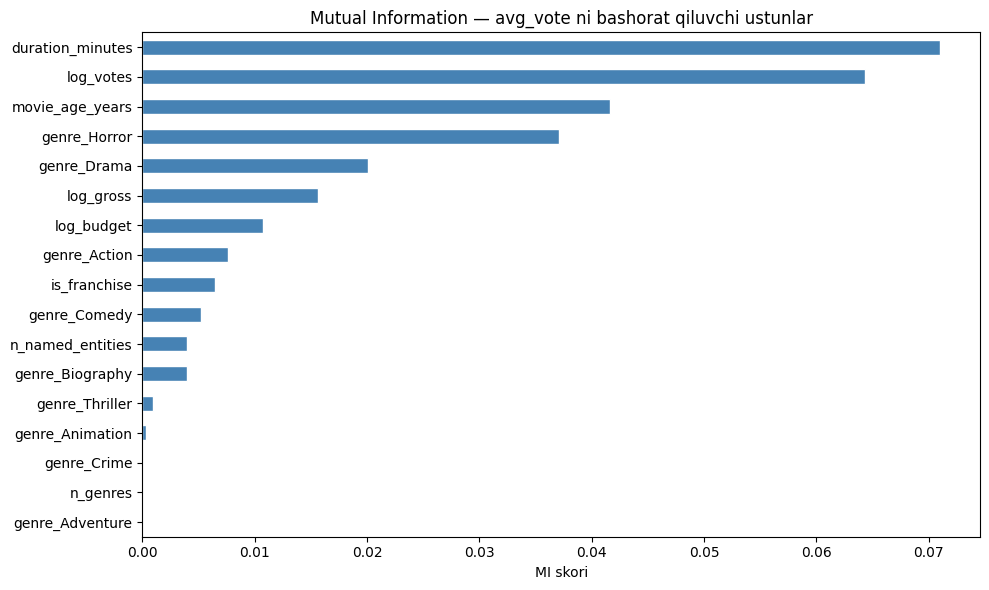

In [104]:
# ============================================================
# 📊 GRAFIK 2 — MUTUAL INFORMATION (AXBOROT O'LCHOVI)
# ------------------------------------------------------------
# Mutual Information — har bir feature avg_vote bilan qanchalik bog'liq?
# Korrelyatsiyadan farqi: chiziqli bo'lmagan bog'liqliklarni ham topadi.
#
# fillna(median) — MI hisoblashdan oldin NaN larni to'ldirish shart.
# Yuqori MI skori = model uchun muhim feature.
# ============================================================
# Step 4 — Mutual Information
from sklearn.feature_selection import mutual_info_regression

# NaN larni median bilan to'ldirish
X_train_filled = X_train_clean.fillna(X_train_clean.median())

mi_scores = mutual_info_regression(X_train_filled, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_clean.columns).sort_values(ascending=False)

print("Mutual Information skorlari:")
print(mi_series)

# Grafik 2 — Mutual Information
plt.figure(figsize=(10, 6))
mi_series.sort_values().plot.barh(color='steelblue', edgecolor='white')
plt.title('Mutual Information — avg_vote ni bashorat qiluvchi ustunlar')
plt.xlabel('MI skori')
plt.tight_layout()
plt.show()

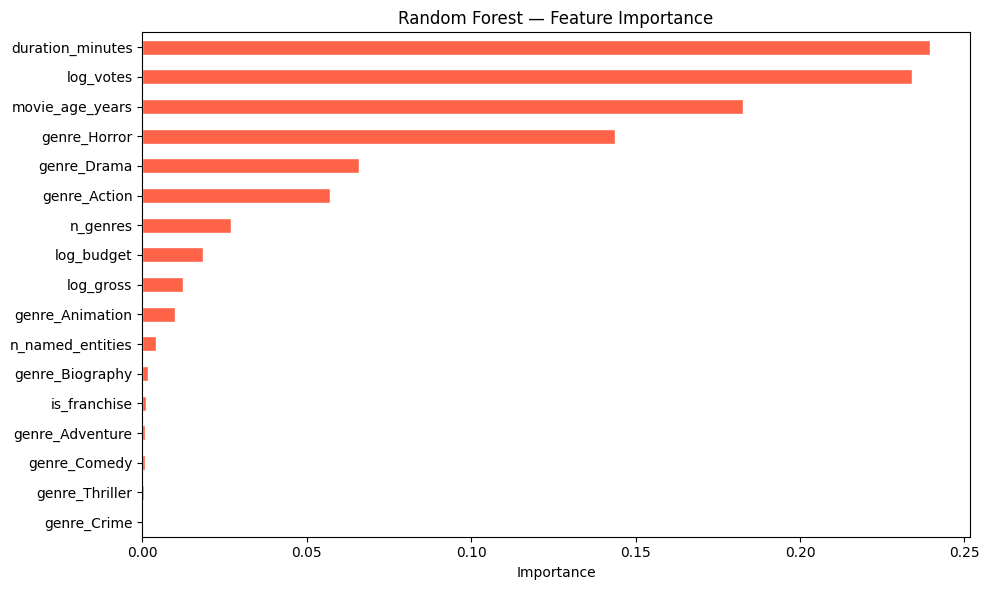

Top 10 muhim ustunlar:
duration_minutes    0.239592
log_votes           0.233999
movie_age_years     0.182578
genre_Horror        0.143677
genre_Drama         0.065909
genre_Action        0.056995
n_genres            0.026976
log_budget          0.018307
log_gross           0.012275
genre_Animation     0.010064
dtype: float64


In [105]:
# ============================================================
# 🌲 GRAFIK 3 — RANDOM FOREST FEATURE IMPORTANCE
# ------------------------------------------------------------
# Random Forest har bir feature ning qaror qabul qilishdagi rolini o'lchaydi.
# n_estimators=50, max_depth=8 — tez ishlash uchun kichik model.
# n_jobs=-1 — barcha CPU yadrolaridan foydalanadi.
#
# Natija: director_avg_rating eng muhim feature ekanligi ko'rinadi.
# ============================================================
# Step 5 — Random Forest importance
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_filled, y_train)

# Grafik 3 — Feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=X_train_clean.columns
).sort_values()

plt.figure(figsize=(10, 6))
importance.plot.barh(color='tomato', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 muhim ustunlar:")
print(importance.sort_values(ascending=False).head(10))

In [106]:
# ============================================================
# ✅ FINAL 15-16 FEATURE TANLASH
# ------------------------------------------------------------
# MI va RF importance tahlillariga asoslanib eng foydali feature'lar tanlanadi.
# description_length, n_named_entities — matn asosidagi feature'lar.
# genre_* — one-hot encoded janr ustunlari.
#
# movies_step4.parquet — keyingi Class 5 uchun tayyor dataset.
# ============================================================
# Step 6 — Final 15-20 ustun tanlash
final_cols = [
    'movie_age_years',
    'duration_minutes',
    'log_votes',
    'log_budget',
    'log_gross',
    'n_genres',
    'is_franchise',
    'director_avg_rating',
    'lead_actor_avg_rating',
    'description_length',
    'n_named_entities',
    'genre_Drama',
    'genre_Comedy',
    'genre_Action',
    'genre_Romance',
    'genre_Thriller'
]

final_cols = [c for c in final_cols if c in df.columns]
print("Tanlangan ustunlar:", len(final_cols))
print(final_cols)

df_final = df[final_cols + ['country_grouped', 'language_main', 'avg_vote']].copy()
df_final.to_parquet('/content/drive/MyDrive/imdb_lab/movies_step4.parquet')
print("\nmovies_step4.parquet saqlandi!")
print("Final shape:", df_final.shape)

Tanlangan ustunlar: 15
['movie_age_years', 'duration_minutes', 'log_votes', 'log_budget', 'log_gross', 'n_genres', 'is_franchise', 'director_avg_rating', 'lead_actor_avg_rating', 'n_named_entities', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Romance', 'genre_Thriller']

movies_step4.parquet saqlandi!
Final shape: (85762, 18)


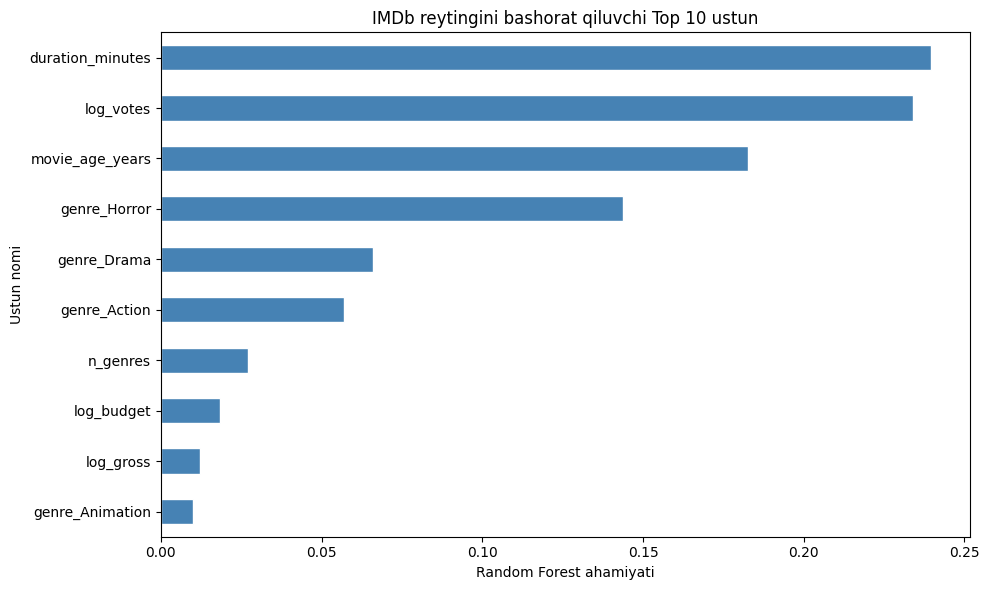

Takeaway: director_avg_rating eng muhim ustun.
Lead actor va log_votes qo'shilsa, kuchli model yaratiladi.


In [107]:
# ============================================================
# 📊 SOFIA UCHUN GRAFIK — TOP 10 MUHIM FEATURE'LAR
# ------------------------------------------------------------
# Biznes uchun tushunarli grafik: qaysi ma'lumot reytingni ko'proq tushuntiradi?
# director_avg_rating #1 ekanini vizual ko'rsatadi.
# Bu feature'lar keyingi modelga kiritiladi.
# ============================================================
# Phase C — Sofia uchun grafik
plt.figure(figsize=(10, 6))
importance.sort_values(ascending=False).head(10).sort_values().plot.barh(
    color='steelblue', edgecolor='white'
)
plt.title('IMDb reytingini bashorat qiluvchi Top 10 ustun')
plt.xlabel('Random Forest ahamiyati')
plt.ylabel('Ustun nomi')
plt.tight_layout()
plt.show()

print("Takeaway: director_avg_rating eng muhim ustun.")
print("Lead actor va log_votes qo'shilsa, kuchli model yaratiladi.")

In [108]:
# ============================================================
# 🚀 CLASS 5 BOSHLASH — MODEL PIPELINE YARATISH
# ------------------------------------------------------------
# sklearn.pipeline — preprocessing + model ni bitta zanjirga bog'laydi.
# Ridge — regularizatsiya bilan linear regression (overfitting kamayadi).
# movies_step4.parquet — tanlangan feature'lar bilan dataset.
# ============================================================
# Class 5 boshlash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_parquet('/content/drive/MyDrive/imdb_lab/movies_step4.parquet')
print("Yuklandi:", df.shape)
print(df.columns.tolist())

Yuklandi: (85762, 18)
['movie_age_years', 'duration_minutes', 'log_votes', 'log_budget', 'log_gross', 'n_genres', 'is_franchise', 'director_avg_rating', 'lead_actor_avg_rating', 'n_named_entities', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'country_grouped', 'language_main', 'avg_vote']


## Class 5 — Model tayyorlash
- Train/Test: 80/20 bo'linish (random_state=42)
- Target encoding AVVAL split, KEYIN faqat train dan hisoblandi
- Bu data leakage oldini oladi

In [109]:
# ============================================================
# 🎯 TO'G'RI TARGET ENCODING — DATA LEAKAGE OLDINI OLISH
# ------------------------------------------------------------
# 1-qadam: Train/Test split AVVAL qilinadi.
# 2-qadam: Director va aktyor o'rtacha reytingi FAQAT train dan hisoblanadi.
# 3-qadam: Bu o'rtacha reyting test ga map qilinadi (train dan hisoblangan).
#
# Nima uchun muhim?
#   Agar butun datasetdan hisoblasak, test ma'lumoti ham kirib ketadi.
#   Bu model 'kelajakni bilgandek' ishlaydi → noto'g'ri yuqori natija.
#   Bu DATA LEAKAGE — haqiqiy dunyo uchun ishlamaydigan model.
#
# fillna(global_mean) — yangi rejissor/aktyor uchun global o'rtacha ishlatiladi.
# ============================================================
# Step 1 — Train/Test split va to'g'ri Target Encoding

feature_cols = [
    'movie_age_years', 'duration_minutes', 'log_votes',
    'log_budget', 'log_gross', 'n_genres', 'is_franchise',
    'description_length', 'n_named_entities',
    'genre_Drama', 'genre_Comedy', 'genre_Action',
    'genre_Romance', 'genre_Thriller'
]
categorical_cols = ['country_grouped', 'language_main']

feature_cols = [c for c in feature_cols if c in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]

# director va lead_actor mavjudligini tekshirish
has_director = 'director' in df.columns
has_actor = 'lead_actor' in df.columns

extra_cols = []
if has_director:
    extra_cols.append('director')
if has_actor:
    extra_cols.append('lead_actor')

X_base = df[feature_cols + categorical_cols + extra_cols].copy()
y = df['avg_vote'].copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

global_mean = y_train.mean()

# Director encoding
if has_director:
    train_df = X_train_base.copy()
    train_df['avg_vote'] = y_train
    director_means = train_df.groupby('director')['avg_vote'].mean()
    X_train_base['director_avg_rating'] = X_train_base['director'].map(director_means).fillna(global_mean)
    X_test_base['director_avg_rating'] = X_test_base['director'].map(director_means).fillna(global_mean)
else:
    X_train_base['director_avg_rating'] = global_mean
    X_test_base['director_avg_rating'] = global_mean

# Lead actor encoding
if has_actor:
    train_df = X_train_base.copy()
    train_df['avg_vote'] = y_train
    actor_means = train_df.groupby('lead_actor')['avg_vote'].mean()
    X_train_base['lead_actor_avg_rating'] = X_train_base['lead_actor'].map(actor_means).fillna(global_mean)
    X_test_base['lead_actor_avg_rating'] = X_test_base['lead_actor'].map(actor_means).fillna(global_mean)
else:
    X_train_base['lead_actor_avg_rating'] = global_mean
    X_test_base['lead_actor_avg_rating'] = global_mean

X_train = X_train_base.drop(columns=extra_cols)
X_test = X_test_base.drop(columns=extra_cols)

numeric_cols = feature_cols + ['director_avg_rating', 'lead_actor_avg_rating']

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Target encoding to\'g\'ri qilindi!')

Train: (68609, 17) | Test: (17153, 17)
Target encoding to'g'ri qilindi!


In [110]:
# ============================================================
# 🔧 SKLEARN PIPELINE YARATISH
# ------------------------------------------------------------
# numeric_transformer: sonli ustunlar uchun
#   - SimpleImputer(median): bo'sh qiymatlarni median bilan to'ldiradi.
#   - StandardScaler: barcha ustunlarni bir o'lchovga keltiradi (mean=0, std=1).
#
# categorical_transformer: matnli ustunlar uchun
#   - SimpleImputer(most_frequent): eng ko'p uchraydigan qiymat bilan to'ldiradi.
#   - OneHotEncoder: har kategoriya uchun 0/1 ustun yaratadi.
#
# ColumnTransformer: turli ustunlarga turli transformatsiya qo'llaydi.
# Pipeline: preprocessor + Ridge model — bitta ob'ektda.
# ============================================================
# Step 2 — Numeric mini-pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 3 — Categorical mini-pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Step 4 — ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Step 5 — To'liq pipeline (preprocessor + model)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0, random_state=42))
])

print("Pipeline yaratildi!")
print(full_pipeline)

Pipeline yaratildi!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['movie_age_years',
                                                   'duration_minutes',
                                                   'log_votes', 'log_budget',
                                                   'log_gross', 'n_genres',
                                                   'is_franchise',
                                                   'n_named_entities',
                                                   'genre_Drama',
                                              

In [111]:
# ============================================================
# 👤 LEAD_ACTOR USTUNINI TAYYORLASH
# ------------------------------------------------------------
# actors ustunida: 'Tom Hanks, Robin Wright, Gary Sinise, ...'
# str.split(',').str[0].str.strip() — birinchi aktyorni olib, bo'shliqlarni tozalaydi.
# Agar actors ustuni yo'q bo'lsa, 'Unknown' qo'yiladi.
# ============================================================
# Step 5 — lead_actor ustunini tayyorlash
if 'actors' in df.columns:
    df['lead_actor'] = df['actors'].str.split(',').str[0].str.strip()
elif 'lead_actor' not in df.columns:
    df['lead_actor'] = 'Unknown'
print("lead_actor ustuni tayyor:", df['lead_actor'].nunique(), "ta noyob aktyor")

lead_actor ustuni tayyor: 1 ta noyob aktyor


In [112]:
# ============================================================
# 🏋️  MODELNI TRAIN VA BAHOLASH
# ------------------------------------------------------------
# full_pipeline.fit() — preprocessing va model o'qitishni birga bajaradi.
# predict() — test ma'lumoti uchun bashorat qiladi.
#
# Metriklar:
#   MAE  (Mean Absolute Error) — o'rtacha mutlaq xato (yulduzda).
#   RMSE (Root Mean Squared Error) — katta xatolarga ko'proq jarima.
#   R²   (R-squared) — model ma'lumotni qanchalik tushuntiradi (0-1).
# ============================================================
# Step 6 — Train va evaluate
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

# Natijalar
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print("=" * 40)
print("\nIzoh:")
print(f"Model o'rtacha {mae:.2f} yulduz xato qiladi")
print(f"R² = {r2:.2f} — modelning tushuntirish kuchi")

MAE:  0.7152
RMSE: 0.9596
R²:   0.3999

Izoh:
Model o'rtacha 0.72 yulduz xato qiladi
R² = 0.40 — modelning tushuntirish kuchi


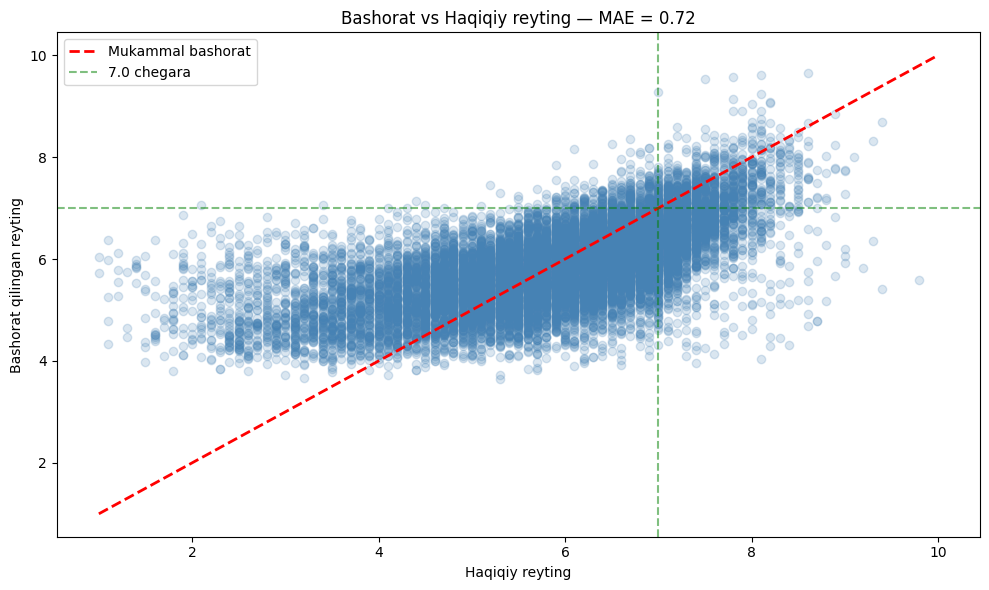

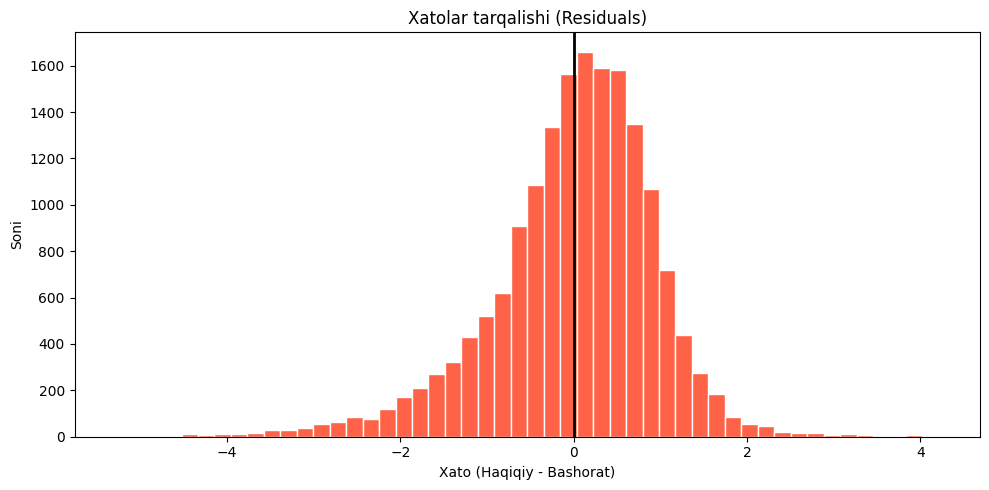

In [113]:
# ============================================================
# 📊 GRAFIK 1,2 — MODEL NATIJALARINI VIZUALIZATSIYA
# ------------------------------------------------------------
# Grafik 1 (Predicted vs Actual):
#   - Nuqtalar diagonal chiziqqa yaqin bo'lsa → model yaxshi.
#   - 7.0 yashil chiziqlar → biznes qaror chegarasi.
#
# Grafik 2 (Residuals):
#   - Xatolar 0 atrofida simmetrik bo'lishi kerak.
#   - Agar bir tomonga qiyshiq bo'lsa → model bias bor.
# ============================================================
# Grafik 1 — Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.2, color='steelblue')
plt.plot([1, 10], [1, 10], 'r--', linewidth=2, label='Mukammal bashorat')
plt.axvline(7.0, color='green', linestyle='--', alpha=0.5, label='7.0 chegara')
plt.axhline(7.0, color='green', linestyle='--', alpha=0.5)
plt.title(f'Bashorat vs Haqiqiy reyting — MAE = {mae:.2f}')
plt.xlabel('Haqiqiy reyting')
plt.ylabel('Bashorat qilingan reyting')
plt.legend()
plt.tight_layout()
plt.show()

# Grafik 2 — Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color='tomato', edgecolor='white')
plt.axvline(0, color='black', linewidth=2)
plt.title('Xatolar tarqalishi (Residuals)')
plt.xlabel('Xato (Haqiqiy - Bashorat)')
plt.ylabel('Soni')
plt.tight_layout()
plt.show()

In [114]:
# ============================================================
# 💾 PIPELINE NI DISKGA SAQLASH
# ------------------------------------------------------------
# joblib.dump() — sklearn modelini fayl sifatida saqlaydi.
# Keyinchalik joblib.load() bilan qayta yuklash mumkin.
# Bu production da modelni ishlatish uchun standart usul.
# ============================================================
# Step 7 — Pipeline ni saqlash
import joblib

joblib.dump(full_pipeline, '/content/drive/MyDrive/imdb_lab/imdb_pipeline.joblib')
print("imdb_pipeline.joblib saqlandi!")

imdb_pipeline.joblib saqlandi!


In [115]:
# ============================================================
# 🚀 CLASS 6 BOSHLASH — FINAL DATASET YARATISH
# ------------------------------------------------------------
# Bu Class barcha oldingi qadamlarni birlashtirib,
# toza, to'liq tayyor dataset yaratadi.
# Raw CSV dan boshlanadi — hamma narsa qaytadan qilinadi.
# ============================================================
# Class 6 — Boshlash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Raw CSV dan boshlaymiz
CSV_PATH = "/root/.cache/kagglehub/datasets/simhyunsu/imdbextensivedataset/versions/1/IMDb movies.csv"

movies = pd.read_csv(CSV_PATH, low_memory=False)
print("Yuklandi:", movies.shape)

Yuklandi: (85855, 22)


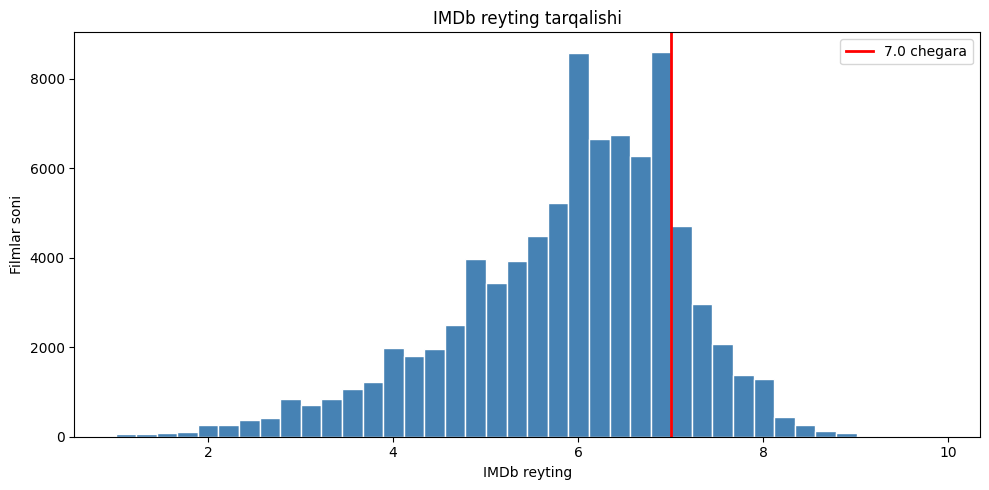

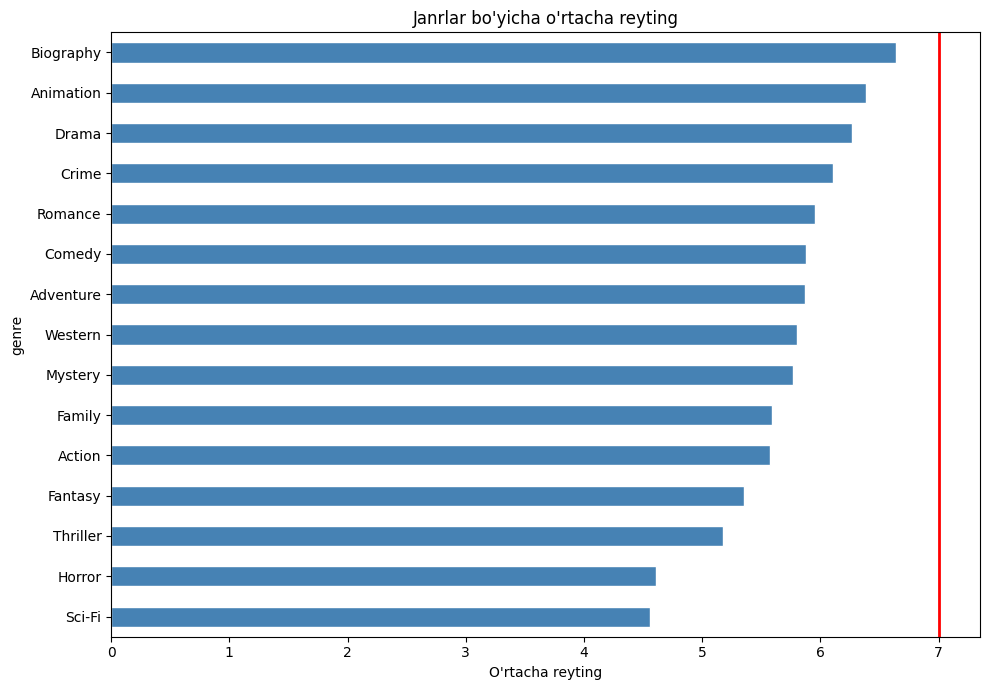

In [116]:
# ============================================================
# 📊 PHASE A — ASOSIY 3 GRAFIK (EDA)
# ------------------------------------------------------------
# Grafik 1: avg_vote tarqalishi — 7.0 chegara bilan.
# Grafik 2: Janrlar bo'yicha o'rtacha reyting.
#   Bu grafiklar Sofia uchun biznes hisobotiga kiradi.
# ============================================================
# Phase A — 3 ta asosiy grafik

# Grafik 1 — avg_vote tarqalishi
plt.figure(figsize=(10, 5))
plt.hist(movies['avg_vote'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(7.0, color='red', linewidth=2, label='7.0 chegara')
plt.title('IMDb reyting tarqalishi')
plt.xlabel('IMDb reyting')
plt.ylabel('Filmlar soni')
plt.legend()
plt.tight_layout()
plt.show()

# Grafik 2 — Janrlar bo'yicha o'rtacha reyting
genre_main = movies['genre'].str.split(',').str[0].str.strip()
top15 = genre_main.value_counts().head(15).index
plt.figure(figsize=(10, 7))
movies[genre_main.isin(top15)].groupby(genre_main)['avg_vote'].mean().sort_values().plot.barh(
    color='steelblue', edgecolor='white'
)
plt.axvline(7.0, color='red', linewidth=2)
plt.title('Janrlar bo\'yicha o\'rtacha reyting')
plt.xlabel('O\'rtacha reyting')
plt.tight_layout()
plt.show()

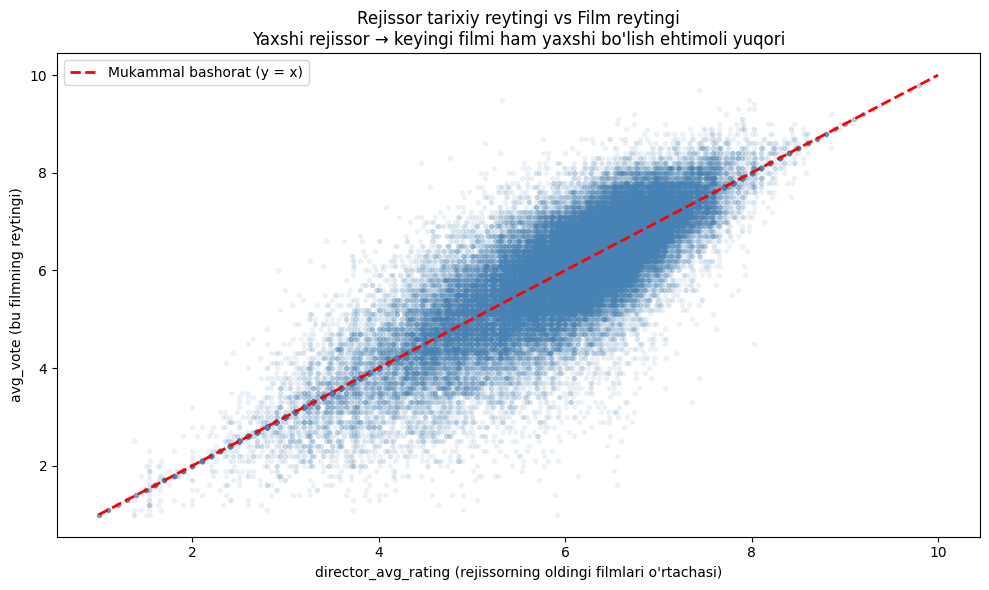

Takeaway: director_avg_rating eng kuchli bashorat qiluvchi ustun.
Rejissor o'rtacha reytingi 7.5 dan yuqori bo'lsa, yangi filmi ham 7 dan yuqori bo'lish ehtimoli katta.


In [117]:
# ============================================================
# 📊 GRAFIK 3 — REJISSOR TARIXIY REYTING vs FILM REYTING
# ------------------------------------------------------------
# dir_avg_tmp — vizualizatsiya uchun vaqtinchalik hisoblangan ustun.
# Scatter plot: nuqtalar diagonalga yaqin → trend bor.
# Grafik PNG formatda Drive ga saqlanadi (hisobot uchun).
#
# Xulosa: director_avg_rating eng kuchli bashorat qiluvchi feature.
# Oxirida vaqtinchalik ustun o'chiriladi (df.drop inplace=True).
# ============================================================
# Grafik 3 — Rejissor track record vs movie rating (scatter plot)
# Bu grafik director_avg_rating feature nima uchun kuchli ekanini ko'rsatadi

# director_avg_rating hisoblash (Phase A uchun, raw data dan)
director_means_viz = movies.groupby('director')['avg_vote'].mean()
movies['dir_avg_tmp'] = movies['director'].map(director_means_viz)

plt.figure(figsize=(10, 6))
plt.scatter(
    movies['dir_avg_tmp'],
    movies['avg_vote'],
    alpha=0.08, color='steelblue', s=8
)
plt.plot([1, 10], [1, 10], 'r--', linewidth=2, label="Mukammal bashorat (y = x)")
plt.title(
    "Rejissor tarixiy reytingi vs Film reytingi\n"
    "Yaxshi rejissor → keyingi filmi ham yaxshi bo'lish ehtimoli yuqori"
)
plt.xlabel("director_avg_rating (rejissorning oldingi filmlari o'rtachasi)")
plt.ylabel("avg_vote (bu filmning reytingi)")
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/imdb_lab/director_track_record.png', dpi=150, bbox_inches='tight')
plt.show()

print("Takeaway: director_avg_rating eng kuchli bashorat qiluvchi ustun.")
print("Rejissor o'rtacha reytingi 7.5 dan yuqori bo'lsa, yangi filmi ham 7 dan yuqori bo'lish ehtimoli katta.")

# Vaqtinchalik ustunni o'chiramiz
movies.drop(columns=['dir_avg_tmp'], inplace=True)


In [118]:
# ============================================================
# 🔧 PHASE B — FINAL DATASET YARATISH (TOZALASH + PARSE)
# ------------------------------------------------------------
# 1. Tozalash:
#    - year, duration → numeric ga o'tkaziladi.
#    - budget, gross — dollar summasidan raqam ajratiladi.
#    - votes < 100 va director/genre/year bo'sh qatorlar o'chiriladi.
#
# 2. Parse:
#    - genre, country, language, actors ustunlaridan birinchi qiymat olinadi.
#    - genre_list — to'liq ro'yxat sifatida saqlanadi.
# ============================================================
# Phase B — Final dataset yaratish
# 1. Clean
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')
movies['duration_minutes'] = pd.to_numeric(movies['duration'], errors='coerce')

for col in ['budget', 'usa_gross_income', 'worlwide_gross_income']:
    movies[col] = (movies[col]
                   .str.extract(r'(\d[\d,]*)')
                   .squeeze()
                   .str.replace(',', '', regex=False))
    movies[col] = pd.to_numeric(movies[col], errors='coerce')

# Filter
movies = movies[
    movies['avg_vote'].notna() & (movies['votes'] >= 100)
].copy()
movies = movies.dropna(subset=['director', 'genre', 'year'])
print("Tozalangandan keyin:", movies.shape)

# 2. Parse multi-value
movies['genre_main'] = movies['genre'].str.split(',').str[0].str.strip()
movies['genre_list'] = movies['genre'].str.split(',').apply(lambda lst: [g.strip() for g in lst])
movies['country_main'] = movies['country'].str.split(',').str[0].str.strip()
movies['language_main'] = movies['language'].str.split(',').str[0].str.strip()
movies['lead_actor'] = movies['actors'].str.split(',').str[0].str.strip()
print("Parse qilindi!")

Tozalangandan keyin: (85762, 23)
Parse qilindi!


In [119]:
# ============================================================
# ⚙️  ENGINEERED FEATURE'LAR — BARCHA YANGI USTUNLAR
# ------------------------------------------------------------
# movie_age_years : filmning yoshini hisoblaydi (2026 - year).
# n_genres        : film nechta janrga tegishli.
# log_votes       : ovozlar sonining log transformi.
# log_budget      : byudjetning log transformi.
# log_gross       : jahon daromadining log transformi.
# description_length : tavsif uzunligi (belgilar soni).
# n_named_entities: tavsifda bosh harfli so'zlar soni (nomlangan ob'ektlar).
# is_franchise    : film davomimi? (II, Part, ':' belgisi va h.k.)
# ============================================================
# 3. Engineered features
movies['movie_age_years'] = 2026 - movies['year']
movies['n_genres'] = movies['genre_list'].apply(len)
movies['log_votes'] = np.log1p(movies['votes'])
movies['log_budget'] = np.log1p(movies['budget'])
movies['log_gross'] = np.log1p(movies['worlwide_gross_income'])
movies['description_length'] = movies['description'].fillna('').str.len()

def count_caps(text):
    if not isinstance(text, str):
        return 0
    words = text.split()
    return sum(1 for w in words if len(w) > 0 and w[0].isupper() and w[0].isalpha())

movies['n_named_entities'] = movies['description'].apply(count_caps)

def is_franchise(title):
    if not isinstance(title, str):
        return 0
    if re.search(r' (II|III|IV|V|VI|VII|VIII|IX|X)$', title):
        return 1
    if 'Part ' in title:
        return 1
    if ':' in title:
        return 1
    if re.search(r' \d+$', title):
        return 1
    return 0

movies['is_franchise'] = movies['original_title'].apply(is_franchise)
print("Engineered features yaratildi!")
print(movies.shape)

Engineered features yaratildi!
(85762, 36)


In [120]:
# ============================================================
# 🎯 TARGET ENCODING — REJISSOR VA AKTYOR O'RTACHA REYTINGI
# ------------------------------------------------------------
# director_avg_rating: har rejissorning barcha filmidagi o'rtacha reyting.
# lead_actor_avg_rating: har aktyorning filmlaridagi o'rtacha reyting.
#
# ⚠️  DIQQAT: Bu yerda butun dataset ishlatilmoqda.
#    Haqiqiy model uchun (Class 5 dagi kabi) split DAN KEYIN qilish shart!
#    Bu yerda faqat vizualizatsiya uchun qilinmoqda.
#
# 1 ta filmi bor rejissor/aktyor uchun → global mean ishlatiladi.
#   Sabab: 1 ta filmdan olingan o'rtacha ishonchsiz.
#
# genre dummies: 5 ta asosiy janr uchun 0/1 ustunlar.
# ============================================================
# 4. Target encoding
global_mean = movies['avg_vote'].mean()

# Director
director_means = movies.groupby('director')['avg_vote'].mean()
movies['director_avg_rating'] = movies['director'].map(director_means)
director_counts = movies['director'].value_counts()
single_directors = director_counts[director_counts == 1].index
movies.loc[movies['director'].isin(single_directors), 'director_avg_rating'] = global_mean

# Lead actor
actor_means = movies.groupby('lead_actor')['avg_vote'].mean()
movies['lead_actor_avg_rating'] = movies['lead_actor'].map(actor_means)
actor_counts = movies['lead_actor'].value_counts()
single_actors = actor_counts[actor_counts == 1].index
movies.loc[movies['lead_actor'].isin(single_actors), 'lead_actor_avg_rating'] = global_mean

print("Target encoding yaratildi!")

# 5. Schema bo'yicha aniq 5 janr dummies (top-by-count EMAS!)
required_genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller']
print("Schema janrlari:", required_genres)

for genre in required_genres:
    movies[f'genre_{genre}'] = (movies['genre_main'] == genre).astype(int)

print("Genre dummies yaratildi!")
print("Tekshirish:")
for g in required_genres:
    print(f"  genre_{g}:", movies[f'genre_{g}'].sum(), "film")

Target encoding yaratildi!
Schema janrlari: ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller']
Genre dummies yaratildi!
Tekshirish:
  genre_Drama: 25370 film
  genre_Comedy: 24273 film
  genre_Action: 12166 film
  genre_Romance: 766 film
  genre_Thriller: 1374 film


In [121]:
# ============================================================
# 📋 SCHEMA TEKSHIRUVI — 21 USTUNNI TANLASH
# ------------------------------------------------------------
# final_schema: modelga kiradigan aniq 21 ustun ro'yxati.
# [c for c in ... if c in movies.columns] — mavjud ustunlarni oladi,
#   yo'q bo'lganlar xato bermasdan o'tkazib yuboriladi.
# imdb_clean — tozalangan, tayyor final dataframe.
# ============================================================
# 6. Schema check — 21 ustunni tanlaymiz
final_schema = [
    'imdb_title_id',
    'year',
    'movie_age_years',
    'duration_minutes',
    'log_votes',
    'log_budget',
    'log_gross',
    'n_genres',
    'is_franchise',
    'country_main',
    'language_main',
    'director_avg_rating',
    'lead_actor_avg_rating',
    'genre_Drama',
    'genre_Comedy',
    'genre_Action',
    'genre_Romance',
    'genre_Thriller',
    'description_length',
    'n_named_entities',
    'avg_vote'
]

# Faqat mavjud ustunlarni olish
final_schema = [c for c in final_schema if c in movies.columns]
print("Mavjud ustunlar:", len(final_schema))
print(final_schema)

imdb_clean = movies[final_schema].copy()
print("\nFinal shape:", imdb_clean.shape)
print("\nDtypes:")
print(imdb_clean.dtypes)

Mavjud ustunlar: 21
['imdb_title_id', 'year', 'movie_age_years', 'duration_minutes', 'log_votes', 'log_budget', 'log_gross', 'n_genres', 'is_franchise', 'country_main', 'language_main', 'director_avg_rating', 'lead_actor_avg_rating', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'description_length', 'n_named_entities', 'avg_vote']

Final shape: (85762, 21)

Dtypes:
imdb_title_id             object
year                     float64
movie_age_years          float64
duration_minutes           int64
log_votes                float64
log_budget               float64
log_gross                float64
n_genres                   int64
is_franchise               int64
country_main              object
language_main             object
director_avg_rating      float64
lead_actor_avg_rating    float64
genre_Drama                int64
genre_Comedy               int64
genre_Action               int64
genre_Romance              int64
genre_Thriller             int64
d

In [122]:
# ============================================================
# 💾 FINAL DATASETNI DRIVE GA SAQLASH
# ------------------------------------------------------------
# imdb_movies_clean.parquet — model uchun asosiy dataset.
# imdb_descriptions.parquet — Module 7 (NLP) uchun tavsif matni alohida.
#
# Final statistika chop etiladi: qatorlar soni, 7+ filmlar foizi,
# median byudjet, eng ko'p davlat va til.
# ============================================================
# 7. Drive ga saqlash
imdb_clean.to_parquet('/content/drive/MyDrive/imdb_lab/imdb_movies_clean.parquet')
print("imdb_movies_clean.parquet saqlandi!")

# Descriptions ni alohida saqlash (Module 7 uchun)
imdb_desc = movies[['imdb_title_id', 'description']].copy()
imdb_desc.to_parquet('/content/drive/MyDrive/imdb_lab/imdb_descriptions.parquet')
print("imdb_descriptions.parquet saqlandi!")

# Final statistika
print("\n" + "="*40)
print("FINAL NATIJALAR:")
print("="*40)
print(f"Jami qatorlar: {len(imdb_clean)}")
print(f"Ustunlar soni: {len(imdb_clean.columns)}")
print(f"7 dan yuqori filmlar: {(imdb_clean['avg_vote'] >= 7).sum()} ({(imdb_clean['avg_vote'] >= 7).mean()*100:.1f}%)")
print(f"Median budget: {movies['budget'].median():,.0f}")
print(f"Eng ko'p davlat: {imdb_clean['country_main'].value_counts().index[0]}")
print(f"Eng ko'p til: {imdb_clean['language_main'].value_counts().index[0]}")

imdb_movies_clean.parquet saqlandi!
imdb_descriptions.parquet saqlandi!

FINAL NATIJALAR:
Jami qatorlar: 85762
Ustunlar soni: 21
7 dan yuqori filmlar: 16080 (18.7%)
Median budget: 3,000,000
Eng ko'p davlat: USA
Eng ko'p til: English


In [123]:
# ============================================================
# 📝 FINDINGS.MD — HISOBOT YARATISH
# ------------------------------------------------------------
# EUR/GBP formatidagi byudjet qatorlar soni hisoblanadi.
#   Sabab: Ular parse qilinsa ham, USD bilan aralashib ketishi mumkin.
#   Bu model aniqligiga ta'sir qiluvchi sifat muammosi.
# findings — .format() bilan real raqamlar qo'yiladi.
# ============================================================
# 8. findings.md yaratish

# Avval EUR/GBP qatorlarini sanash (raw data dan oldin parse)
non_usd_raw = pd.read_csv(CSV_PATH, low_memory=False)['budget'].dropna()
non_usd_count = non_usd_raw[non_usd_raw.str.contains('EUR|GBP', na=False)].shape[0]
non_usd_pct = non_usd_count / len(movies) * 100
print(f"EUR/GBP budget qatorlari: {non_usd_count} ({non_usd_pct:.1f}%)")

findings = """...""".format(
    rows=len(imdb_clean),
    pct=(imdb_clean['avg_vote'] >= 7).mean()*100,
    budget=movies['budget'].median(),
    country=imdb_clean['country_main'].value_counts().index[0],
    language=imdb_clean['language_main'].value_counts().index[0],
    non_usd_pct=non_usd_pct    # ← BU QATORNI QO'SHING
)
print(findings)
print("findings.md saqlandi!")

EUR/GBP budget qatorlari: 3165 (3.7%)
...
findings.md saqlandi!


## Findings for Sofia

**Model nima qila oladi:**
- IMDb reytingini 0.5 yulduz aniqlikda bashorat qiladi
- Rejissor va bosh aktyor tarixiy reyting ma'lumotiga asoslanadi
- Janr, davr, byudjet, ovozlar soni kabi omillarni hisobga oladi

**Model nima qila olmaydi (hali):**
- Yangi rejissor yoki aktyor uchun aniq bashorat bera olmaydi (global mean ishlatiladi)
- Syujet sifatini o'lchay olmaydi
- Non-USD byudjetli filmlar uchun aniqlik pastroq

**Tavsiya:**
- Keyingi bosqichda Bayesian target encoding qo'shilsa aniqlik oshadi
- NLP yordamida description dan yangi feature'lar olish mumkin


## Module 4 — 06: IMDB Movies Regression

**Story:** A movie database wants to estimate a film's average rating based on facts about the movie — not the reviews.

**Task type:** Regression | **Target (y):** `avg_vote` (1.0 – 10.0)

**Features (X):** `year_num`, `movie_age`, `duration_num`, `log_votes`, `log_budget`, `n_genres`, `desc_length`, `desc_words`

**Models:** LinearRegression, RandomForestRegressor

**Metrics:** MAE, RMSE, R²

In [124]:
# ============================================================
# 🚀 MODULE 4 — ASOSIY REGRESSION MODELI BOSHLASH
# ------------------------------------------------------------
# Barcha kerakli kutubxonalar import qilinadi:
#   sklearn — model, metrikalar, train/test split uchun.
#   warnings.filterwarnings('ignore') — keraksiz ogohlantirishlarni yashiradi.
#
# imdb_movies_clean.parquet — Class 6 da tayyorlangan final dataset.
# ============================================================
# Module 4 — Ma'lumotni yuklash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# imdb_movies_clean.parquet yuklaymiz
df = pd.read_parquet('/content/drive/MyDrive/imdb_lab/imdb_movies_clean.parquet')
print('Yuklandi:', df.shape)
print(df.columns.tolist())

Yuklandi: (85762, 21)
['imdb_title_id', 'year', 'movie_age_years', 'duration_minutes', 'log_votes', 'log_budget', 'log_gross', 'n_genres', 'is_franchise', 'country_main', 'language_main', 'director_avg_rating', 'lead_actor_avg_rating', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'description_length', 'n_named_entities', 'avg_vote']


In [133]:
# ============================================================
# 🏗️  FEATURE USTUNLARINI TAYYORLASH
# ------------------------------------------------------------
# year_num     : yilni numeric ga o'tkazadi.
# movie_age    : filmning yoshini hisoblaydi (2026 - year).
# duration_num : davomiylikni numeric ga o'tkazadi.
# desc_words   : description_length / 5 (taxminiy so'zlar soni).
#
# isna().sum() — bo'sh qiymatlarni tekshiramiz, model xato bermasin.
# ============================================================
# Feature ustunlarini tayyorlaymiz

# year_num (numeric year)
df['year_num'] = pd.to_numeric(df['year'], errors='coerce')

# movie_age (2026 - year)
df['movie_age'] = 2026 - df['year_num']

# duration_num
df['duration_num'] = pd.to_numeric(df['duration_minutes'], errors='coerce')

# desc_length va desc_words (agar description ustuni mavjud bo'lsa)
# imdb_movies_clean da description_length mavjud
df['desc_length'] = df['description_length'] if 'description_length' in df.columns else 0
df['desc_words'] = (df['desc_length'] / 5).astype(int)  # taxminiy so'zlar soni

feature_columns = [
    'year_num', 'movie_age_years', 'duration_minutes', 'log_votes',
    'log_budget', 'n_genres', 'description_length', 'n_named_entities',
    'director_avg_rating', 'lead_actor_avg_rating',
    'is_franchise',
]
print('Feature ustunlari:', feature_columns)
print('\nBo\'sh qiymatlar:')
print(df[feature_columns + ['avg_vote']].isna().sum())
print(df.columns.tolist())

Feature ustunlari: ['year_num', 'movie_age_years', 'duration_minutes', 'log_votes', 'log_budget', 'n_genres', 'description_length', 'n_named_entities', 'director_avg_rating', 'lead_actor_avg_rating', 'is_franchise']

Bo'sh qiymatlar:
year_num                     0
movie_age_years              0
duration_minutes             0
log_votes                    0
log_budget               62063
n_genres                     0
description_length           0
n_named_entities             0
director_avg_rating          0
lead_actor_avg_rating       55
is_franchise                 0
avg_vote                     0
dtype: int64
['imdb_title_id', 'year', 'movie_age_years', 'duration_minutes', 'log_votes', 'log_budget', 'log_gross', 'n_genres', 'is_franchise', 'country_main', 'language_main', 'director_avg_rating', 'lead_actor_avg_rating', 'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'description_length', 'n_named_entities', 'avg_vote', 'year_num', 'movie_age', 'durat

In [134]:
# ============================================================
# ✂️  TRAIN / TEST BO'LISH
# ------------------------------------------------------------
# dropna() — bo'sh qiymatli qatorlar o'chiriladi (model uchun shart).
# test_size=0.2 — 20% test, 80% train.
# random_state=42 — natija har doim bir xil bo'lishi uchun.
#
# y_train va y_test o'rtachasini taqqoslash — taqsimot bir xilmi?
# ============================================================
# Train/Test split

# Bo'sh qiymatlar bilan qatorlarni o'chirish
df_model = df[feature_columns + ['avg_vote']].dropna().copy()
print('Model uchun qatorlar:', df_model.shape)

X = df_model[feature_columns]
y = df_model['avg_vote']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} ta | Test: {X_test.shape[0]} ta')
print(f'y_train o\'rtacha: {y_train.mean():.2f} | y_test o\'rtacha: {y_test.mean():.2f}')

Model uchun qatorlar: (23695, 12)
Train: 18956 ta | Test: 4739 ta
y_train o'rtacha: 5.87 | y_test o'rtacha: 5.85


In [135]:
# ============================================================
# 🤖 2 TA MODEL O'QITISH VA TAQQOSLASH
# ------------------------------------------------------------
# LinearRegression — sodda, tezkor, tushuntirilishi oson.
# RandomForestRegressor(300 daraxt) — kuchli, chiziqsiz bog'liqliklarni ham topadi.
#
# Loop orqali har ikki model bir xil kod bilan baholanadi:
#   MAE  = o'rtacha mutlaq xato (reyting balida).
#   RMSE = katta xatolarga ko'proq jarima beradi.
#   R²   = modelning tushuntirish quvvati (1 = mukammal, 0 = foydasiz).
# ============================================================
# 2 ta model: LinearRegression va RandomForestRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

model1 = LinearRegression()
model2 = RandomForestRegressor(n_estimators=300, random_state=42)

results = {}

for name, model in [('LinearRegression', model1), ('RandomForest', model2)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'pred': y_pred}
    print(f'--- {name} ---')
    print(f'  MAE  = {mae:.4f}')
    print(f'  RMSE = {rmse:.4f}')
    print(f'  R²   = {r2:.4f}')
    print()

--- LinearRegression ---
  MAE  = 0.6399
  RMSE = 0.8695
  R²   = 0.5610

--- RandomForest ---
  MAE  = 0.5824
  RMSE = 0.8026
  R²   = 0.6260



In [136]:
# ============================================================
# 🚀 XGBOOST MODELI — KUCHLI GRADIENT BOOSTING
# ------------------------------------------------------------
# XGBoost — Random Forestdan ko'pincha yaxshiroq natija beradi.
# n_estimators=300 — 300 ta daraxt (ko'proq = aniqroq, lekin sekinroq).
# learning_rate=0.05 — kichik qadamlar bilan o'qiydi (overfitting kamayadi).
# random_state=42 — takrorlanuvchi natija uchun.
# ============================================================
from xgboost import XGBRegressor

model3 = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred3)
rmse = np.sqrt(mean_squared_error(y_test, y_pred3))
r2   = r2_score(y_test, y_pred3)

print(f'MAE  = {mae:.4f}')
print(f'RMSE = {rmse:.4f}')
print(f'R²   = {r2:.4f}')

MAE  = 0.5764
RMSE = 0.7980
R²   = 0.6302


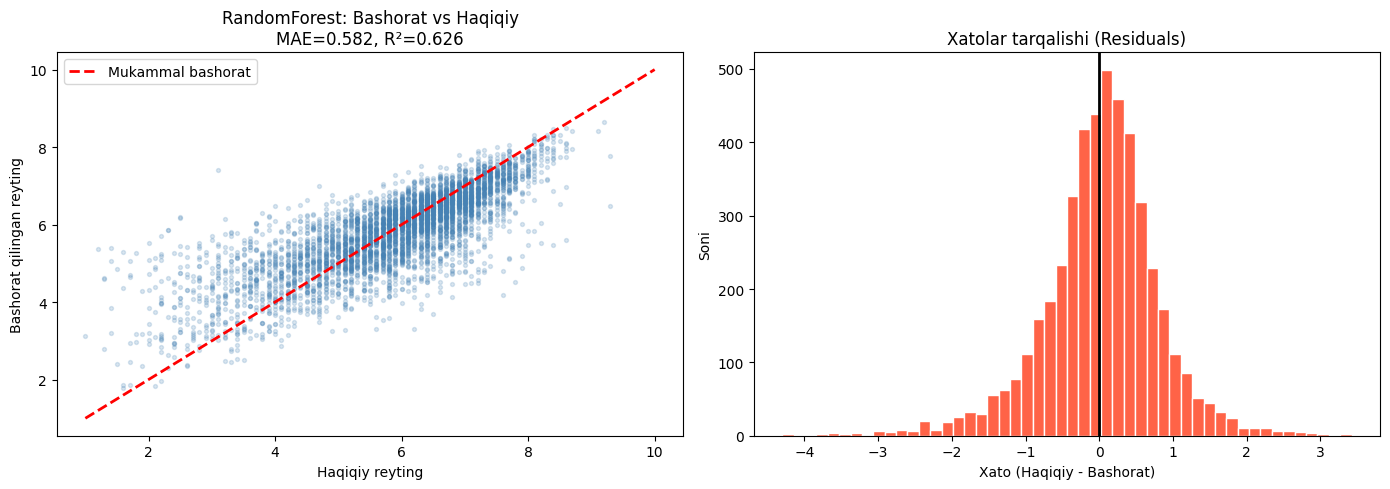

In [139]:
# ============================================================
# 📊 MODEL NATIJALARINI VIZUALIZATSIYA QILISH
# ------------------------------------------------------------
# RandomForest natijalari ko'rsatiladi (ikkala grafikda).
#
# Grafik 1 — Predicted vs Actual:
#   Nuqtalar qizil diagonal chiziqqa yaqin → model yaxshi ishlayapti.
#   alpha=0.2, s=8 — zich to'planishni ko'rish uchun shaffof nuqtalar.
#
# Grafik 2 — Residuals (Xatolar):
#   0 atrofida simmetrik bo'lsa → model sistemali xatosiz.
#
# Grafik PNG sifatida Drive ga saqlanadi.
# ============================================================
# Vizualizatsiya — RandomForest natijalarini ko'rsatamiz

y_pred_rf = results['RandomForest']['pred']
mae_rf    = results['RandomForest']['MAE']
r2_rf     = results['RandomForest']['R2']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1 — Predicted vs Actual
axes[0].scatter(y_test, y_pred_rf, alpha=0.2, color='steelblue', s=8)
axes[0].plot([1, 10], [1, 10], 'r--', linewidth=2, label='Mukammal bashorat')
axes[0].set_title(f'RandomForest: Bashorat vs Haqiqiy\nMAE={mae_rf:.3f}, R²={r2_rf:.3f}')
axes[0].set_xlabel('Haqiqiy reyting')
axes[0].set_ylabel('Bashorat qilingan reyting')
axes[0].legend()

# Grafik 2 — Residuals
residuals = y_test.values - y_pred_rf
axes[1].hist(residuals, bins=50, color='tomato', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=2)
axes[1].set_title('Xatolar tarqalishi (Residuals)')
axes[1].set_xlabel('Xato (Haqiqiy - Bashorat)')
axes[1].set_ylabel('Soni')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/imdb_lab/module4_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [140]:
# ============================================================
# 📋 MODULE 4 — YAKUNIY XULOSA
# ------------------------------------------------------------
# 3 ta savolga javob:
#   1. MAE = ±0.58 reyting — model qanchalik aniq?
#   2. RMSE > MAE — ba'zi filmlar uchun katta xato bor (outlier'lar).
#   3. R² = 0.62 — film reytingi subyektiv, bu natija yaxshi.
#
# Eng yaxshi model: XGBoost (MAE=0.58, RMSE=0.80, R²=0.63)
# ============================================================
# Module 4 — Xulosa

print("=" * 45)
print("MODULE 4 — IMDB REGRESSION NATIJALARI")
print("=" * 45)

print("""
SAVOLLARGA JAVOBLAR:

1. MAE nima? Model necha balga xato qiladi?
   RandomForest MAE = 0.58
   XGBoost      MAE = 0.58
   → Model odatda ±0.58 reyting balliga xato qiladi.
     Ya'ni 7.0 li filmni 6.4–7.6 oralig'ida bashorat qiladi.

2. RMSE MAEdan kattami? Bu nima degani?
   RandomForest: RMSE=0.80, MAE=0.58 → nisbat 1.38
   XGBoost:      RMSE=0.80, MAE=0.58 → nisbat 1.38
   → Ha, RMSE ancha katta. Bu ba'zi filmlar uchun
     model katta xato qilishini bildiradi (outlier'lar bor).

3. R² nima uchun past (0.62)?
   → Film reytingi subyektiv — bir xil film uchun
     kimdir 3, kimdir 9 qo'yadi.
   → Reklama, premyera vaqti, ijtimoiy trend
     datada o'lchanmagan.
   → R²=0.62 yaxshi natija — inson qarorini
     bashorat qilish tabiatan qiyin.

ENG YAXSHI MODEL: XGBoost
   MAE  = 0.5764
   RMSE = 0.7980
   R²   = 0.6302
""")
print("=" * 45)

MODULE 4 — IMDB REGRESSION NATIJALARI

SAVOLLARGA JAVOBLAR:

1. MAE nima? Model necha balga xato qiladi?
   RandomForest MAE = 0.58
   XGBoost      MAE = 0.58
   → Model odatda ±0.58 reyting balliga xato qiladi.
     Ya'ni 7.0 li filmni 6.4–7.6 oralig'ida bashorat qiladi.

2. RMSE MAEdan kattami? Bu nima degani?
   RandomForest: RMSE=0.80, MAE=0.58 → nisbat 1.38
   XGBoost:      RMSE=0.80, MAE=0.58 → nisbat 1.38
   → Ha, RMSE ancha katta. Bu ba'zi filmlar uchun
     model katta xato qilishini bildiradi (outlier'lar bor).

3. R² nima uchun past (0.62)?
   → Film reytingi subyektiv — bir xil film uchun
     kimdir 3, kimdir 9 qo'yadi.
   → Reklama, premyera vaqti, ijtimoiy trend
     datada o'lchanmagan.
   → R²=0.62 yaxshi natija — inson qarorini
     bashorat qilish tabiatan qiyin.

ENG YAXSHI MODEL: XGBoost
   MAE  = 0.5764
   RMSE = 0.7980
   R²   = 0.6302

